# TFM — EDA II: Análisis a nivel accidente
**Autora:** Meritxell Abellan Collado  
**Dataset:** Accidentes de tráfico en Madrid (Open Data Ayuntamiento de Madrid)  

---

## Objetivo de este notebook

El objetivo del modelo es predecir si un **accidente** será grave o no, no si una persona concreta resultará herida. Por ello, este notebook trabaja con el dataset agregado a nivel accidente (`df_accidentes`), donde cada fila representa un accidente único.

Se analizan las variables externas al accidente (temporales, geográficas, condiciones de la vía) y su relación con la variable objetivo `accidente_grave`.

> El análisis descriptivo del dataset original (nivel persona) se encuentra en `01_EDA_personas.ipynb`.

---
## 0. Carga de librerías y datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, shapiro, kstest
import warnings

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Paleta de colores global para lesividad
COLORES_LESIVIDAD = {'IL': '#2ecc71', 'HL': '#f1c40f', 'HG': '#e67e22', 'MT': '#e74c3c'}
ORDEN_LESIVIDAD = ['IL', 'HL', 'HG', 'MT']

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [3]:
# Carga del dataset
DATA_PATH = '../data/raw/accidentes-trafico.xlsx'

df = pd.read_excel(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas')

Dataset cargado: 199,078 filas | 26 columnas


El dataset incluye registros de testigos, que no están directamente implicados en los accidentes y que pueden distorsionar el estudio. Por ello, se suprimen de manera que solo se tienen en consideración los implicados directos en cada accidente.

Además, en esta celda se construyen **dos dataframes de trabajo globales** que se usarán a lo largo de todo el notebook:
- `df`: todos los registros sin testigos (nivel persona)
- `df_sin_na`: ídem, excluyendo también los registros con `LESIVIDAD = 'NO ASIGNADA'`, con la columna binaria `GRAVE` ya calculada

In [4]:
# --- Exclusión de testigos ---
df['TIPO PERSONA'] = df['TIPO PERSONA'].str.strip()
n_testigos = (df['TIPO PERSONA'] == 'TESTIGO').sum()
df = df[df['TIPO PERSONA'] != 'TESTIGO'].copy()

# --- Conversión de fecha ---
df['FECHA'] = pd.to_datetime(df['FECHA'])
df['AÑO']  = df['FECHA'].dt.year
df['MES']  = df['FECHA'].dt.month

# --- Limpieza de columnas clave (strip) ---
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

# --- Dataframe global sin LESIVIDAD 'NO ASIGNADA' y con columna GRAVE ---
df_sin_na = df[df['LESIVIDAD'].isin(ORDEN_LESIVIDAD)].copy()
df_sin_na['GRAVE'] = df_sin_na['LESIVIDAD'].isin(['HG', 'MT']).astype(int)

print(f'Registros originales:             {len(df) + n_testigos:>8,}')
print(f'Testigos excluidos:               {n_testigos:>8,}')
print(f'Registros nivel persona (df):     {len(df):>8,}')
print(f'  └─ Sin LESIVIDAD NO ASIGNADA:   {len(df_sin_na):>8,}')
print(f'Accidentes únicos:                {df["Nº PARTE"].nunique():>8,}')

Registros originales:              199,078
Testigos excluidos:                 24,725
Registros nivel persona (df):      174,353
  └─ Sin LESIVIDAD NO ASIGNADA:    166,493
Accidentes únicos:                  68,773


### Nota sobre la estructura de dataframes y coherencia con `01_EDA_personas.ipynb`

En este notebook se usan dos dataframes de trabajo globales:

- **`df`** — todos los implicados directos (sin testigos), incluyendo los registros con `LESIVIDAD = 'NO ASIGNADA'`. Se usa en análisis descriptivos que no dependen de la lesividad (temporales, geográficos...).
- **`df_sin_na`** — subconjunto de `df` con lesividad conocida (`IL`, `HL`, `HG`, `MT`). Los 7.860 registros con `LESIVIDAD = 'NO ASIGNADA'` quedan excluidos, **de forma equivalente a como en `01_EDA_personas.ipynb` esos mismos registros se convierten a `NaN`**. Incluye la columna binaria `GRAVE` (1 = HG o MT).
- **`df_accidentes`** — dataset agregado a nivel accidente con la variable objetivo `accidente_grave`.

Esta estructura garantiza coherencia entre ambos notebooks: los registros sin lesividad asignada se excluyen siempre de los análisis de gravedad.

---
## 1. Transformación: de nivel persona a nivel accidente

Dado que el objetivo del trabajo es predecir la gravedad del **accidente** (no la de los implicados), se transforma el dataset desde una estructura a nivel persona a una estructura a nivel accidente.

Para ello se agregan los registros por identificador de accidente (`Nº PARTE`) y se define la **variable objetivo** como la máxima lesividad registrada entre todos sus implicados:

- `accidente_grave = 1` si algún implicado resultó herido grave o fallecido
- `accidente_grave = 0` en caso contrario (ilesos y heridos leves)

Las variables contextuales del accidente (fecha, distrito, tipo de vía, condiciones meteorológicas...) se toman de la primera fila de cada grupo, ya que son idénticas para todos los implicados de un mismo accidente.

In [5]:
GRAVES = ['HG', 'MT']

# Variables del accidente (iguales para todos los implicados del mismo accidente)
vars_accidente = [
    'FECHA', 'AÑO', 'MES', 'DIA SEMANA', 'RANGO HORARIO',
    'DISTRITO', 'LUGAR ACCIDENTE', 'TIPO ACCIDENTE',
    'Nº VICTIMAS *',
    *[c for c in df.columns if c.startswith('CPFA') or c.startswith('CPSV')]
]

df_accidentes = (
    df_sin_na.groupby('Nº PARTE')
    .agg(
        **{var: (var, 'first') for var in vars_accidente if var in df_sin_na.columns},
        accidente_grave=('LESIVIDAD', lambda x: int(x.isin(GRAVES).any())),
        n_implicados=('LESIVIDAD', 'count'),
    )
    .reset_index()
)

print(f'Accidentes únicos: {len(df_accidentes):,}')
print(f'\nDistribución de accidente_grave:')
print(df_accidentes['accidente_grave'].value_counts())
pct_graves = df_accidentes['accidente_grave'].mean() * 100
print(f'\n% accidentes graves: {pct_graves:.1f}%')
print(f'Ratio desequilibrio: ~{(100-pct_graves)/pct_graves:.0f}:1')

Accidentes únicos: 68,773

Distribución de accidente_grave:
accidente_grave
0    62169
1     6604
Name: count, dtype: int64

% accidentes graves: 9.6%
Ratio desequilibrio: ~9:1


---
## 2. Análisis univariante: Nº de víctimas por accidente

`Nº VICTIMAS *` es la única variable numérica del dataset. Recoge el número de víctimas (personas heridas, graves o fallecidas) por accidente. Al ser una variable a nivel accidente, el análisis se realiza directamente sobre `df_accidentes`.

Se analiza su distribución, estadísticos descriptivos, normalidad y su relación con la variable objetivo `accidente_grave`.

In [6]:
# Estadísticos descriptivos de Nº VICTIMAS *
victimas_serie = df_accidentes['Nº VICTIMAS *'].dropna()

desc = {
    'Recuento':             victimas_serie.count(),
    'Media':                victimas_serie.mean(),
    'Mediana':              victimas_serie.median(),
    'Moda':                 victimas_serie.mode()[0],
    'Desviación estándar':  victimas_serie.std(),
    'Varianza':             victimas_serie.var(),
    'Mínimo':               victimas_serie.min(),
    'Q1 (25%)':             victimas_serie.quantile(0.25),
    'Q3 (75%)':             victimas_serie.quantile(0.75),
    'IQR':                  victimas_serie.quantile(0.75) - victimas_serie.quantile(0.25),
    'Máximo':               victimas_serie.max(),
    'Asimetría (skewness)': victimas_serie.skew(),
    'Curtosis (kurtosis)':  victimas_serie.kurtosis(),
}

for k, v in desc.items():
    print(f'{k:<28}: {v:.4f}' if isinstance(v, float) else f'{k:<28}: {v}')

# Límites de outliers (criterio IQR)
iqr     = desc['IQR']
lim_inf = desc['Q1 (25%)'] - 1.5 * iqr
lim_sup = desc['Q3 (75%)'] + 1.5 * iqr
n_outliers = ((victimas_serie < lim_inf) | (victimas_serie > lim_sup)).sum()
print(f'\nLímite inferior outliers (IQR): {lim_inf:.2f}')
print(f'Límite superior outliers (IQR): {lim_sup:.2f}')
print(f'Accidentes con outliers:        {n_outliers:,} ({n_outliers/len(victimas_serie)*100:.2f}%)')

Recuento                    : 68773
Media                       : 1.2791
Mediana                     : 1.0000
Moda                        : 1
Desviación estándar         : 0.7213
Varianza                    : 0.5203
Mínimo                      : 1
Q1 (25%)                    : 1.0000
Q3 (75%)                    : 1.0000
IQR                         : 0.0000
Máximo                      : 19
Asimetría (skewness)        : 4.6835
Curtosis (kurtosis)         : 43.9921

Límite inferior outliers (IQR): 1.00
Límite superior outliers (IQR): 1.00
Accidentes con outliers:        13,035 (18.95%)


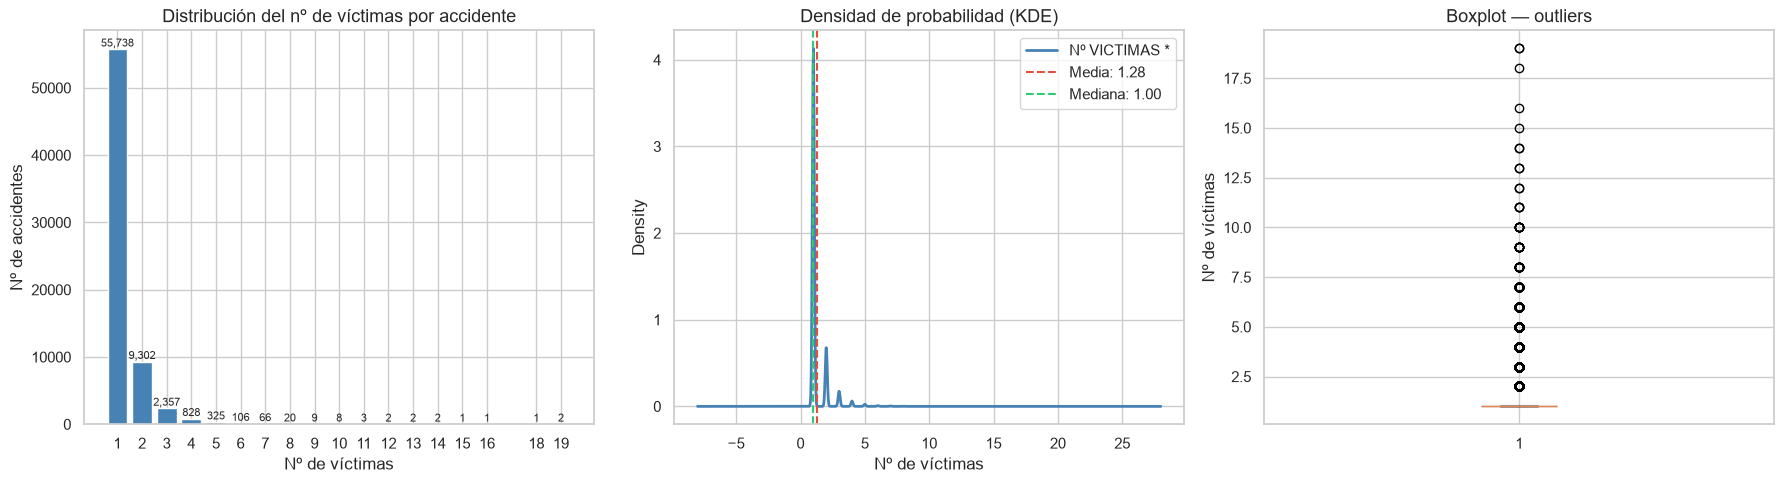

In [7]:
# Distribución: histograma, KDE y boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vc = victimas_serie.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
for x, y in zip(vc.index, vc.values):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Distribución del nº de víctimas por accidente', fontsize=13)
axes[0].set_xlabel('Nº de víctimas'); axes[0].set_ylabel('Nº de accidentes')
axes[0].set_xticks(vc.index)

victimas_serie.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].axvline(victimas_serie.mean(),   color='#e74c3c', linestyle='--',
                label=f'Media: {victimas_serie.mean():.2f}')
axes[1].axvline(victimas_serie.median(), color='#2ecc71', linestyle='--',
                label=f'Mediana: {victimas_serie.median():.2f}')
axes[1].set_title('Densidad de probabilidad (KDE)', fontsize=13)
axes[1].set_xlabel('Nº de víctimas'); axes[1].legend()

axes[2].boxplot(victimas_serie, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[2].set_title('Boxplot — outliers', fontsize=13)
axes[2].set_ylabel('Nº de víctimas')

plt.tight_layout()
plt.savefig('../figures/06_distribucion_victimas.png', dpi=150)
plt.show()

In [24]:
# Test de normalidad — Kolmogorov-Smirnov
from scipy.stats import kstest, norm as sp_norm

n_muestra = min(5000, len(victimas_serie))
muestra   = victimas_serie.sample(n_muestra, random_state=42)

frozen = sp_norm(loc=muestra.mean(), scale=muestra.std())
stat_ks, p_ks = kstest(muestra, frozen.cdf)

print(f'Test Kolmogorov-Smirnov (n={n_muestra:,}):')
print(f'  Estadístico KS = {stat_ks:.4f}')
print(f'  p-valor        = {p_ks:.4e}')
if p_ks < 0.05:
    print('  ✗ Se rechaza la hipótesis de normalidad (p < 0.05).')
    print('  → Distribución no normal: asimetría positiva / cola derecha.')
    print('  → Se usará Mann-Whitney U para comparar grupos (no paramétrico).')
else:
    print('  ✓ No se rechaza la hipótesis de normalidad.')

Test Kolmogorov-Smirnov (n=5,000):
  Estadístico KS = 0.4702
  p-valor        = 0.0000e+00
  ✗ Se rechaza la hipótesis de normalidad (p < 0.05).
  → Distribución no normal: asimetría positiva / cola derecha.
  → Se usará Mann-Whitney U para comparar grupos (no paramétrico).


In [25]:
# Test Mann-Whitney U: ¿difiere el nº de víctimas entre accidentes graves y no graves?
from scipy.stats import mannwhitneyu

graves    = df_accidentes.loc[df_accidentes['accidente_grave'] == 1, 'Nº VICTIMAS *'].dropna()
no_graves = df_accidentes.loc[df_accidentes['accidente_grave'] == 0, 'Nº VICTIMAS *'].dropna()

stat_mw, p_mw = mannwhitneyu(graves, no_graves, alternative='two-sided')

print('Test Mann-Whitney U — Nº VICTIMAS * entre accidentes graves y no graves:')
print(f'  Media graves:    {graves.mean():.3f}  |  Mediana: {graves.median():.1f}')
print(f'  Media no graves: {no_graves.mean():.3f}  |  Mediana: {no_graves.median():.1f}')
print(f'  Estadístico U  = {stat_mw:.0f}')
print(f'  p-valor        = {p_mw:.4e}')
print()
if p_mw < 0.05:
    print('  ✓ Diferencia estadísticamente significativa (p < 0.05).')
    print('  → Los accidentes graves tienden a tener más víctimas que los no graves.')
else:
    print('  ✗ No hay diferencia estadísticamente significativa.')

Test Mann-Whitney U — Nº VICTIMAS * entre accidentes graves y no graves:
  Media graves:    1.310  |  Mediana: 1.0
  Media no graves: 1.276  |  Mediana: 1.0
  Estadístico U  = 207833505
  p-valor        = 1.4733e-02

  ✓ Diferencia estadísticamente significativa (p < 0.05).
  → Los accidentes graves tienden a tener más víctimas que los no graves.


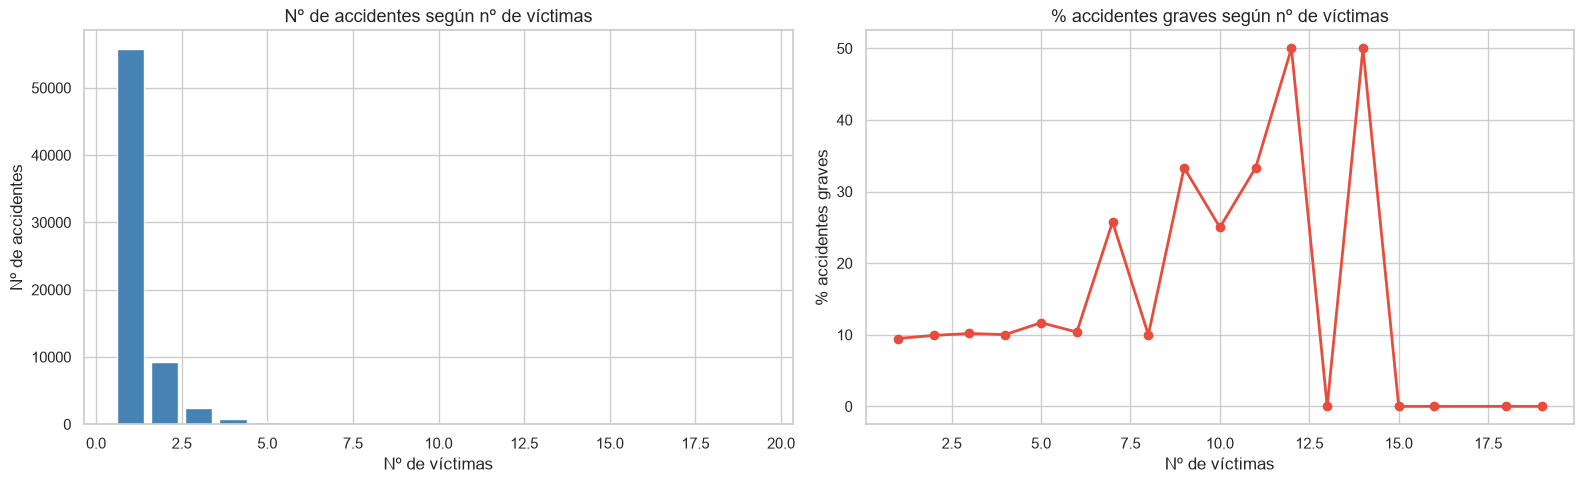

In [26]:
# Relación entre nº de víctimas y tasa de accidentes graves
tasa_grave_vic = (df_accidentes.groupby('Nº VICTIMAS *')['accidente_grave']
                               .agg(['mean', 'count'])
                               .rename(columns={'mean': 'pct_grave', 'count': 'n_accidentes'})
                               .assign(pct_grave=lambda x: x['pct_grave'] * 100)
                               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(tasa_grave_vic['Nº VICTIMAS *'], tasa_grave_vic['n_accidentes'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Nº de accidentes según nº de víctimas', fontsize=13)
axes[0].set_xlabel('Nº de víctimas'); axes[0].set_ylabel('Nº de accidentes')

axes[1].plot(tasa_grave_vic['Nº VICTIMAS *'], tasa_grave_vic['pct_grave'],
             marker='o', color='#e74c3c', linewidth=2)
axes[1].set_title('% accidentes graves según nº de víctimas', fontsize=13)
axes[1].set_xlabel('Nº de víctimas'); axes[1].set_ylabel('% accidentes graves')

plt.tight_layout()
plt.savefig('../figures/06b_victimas_vs_gravedad.png', dpi=150)
plt.show()

### 2.2 Análisis de `n_implicados` (número de personas implicadas por accidente)

In [ ]:
# n_implicados: estadísticos descriptivos y relación con la gravedad
n_impl = df_accidentes['n_implicados']

print('Estadísticos descriptivos — nº de implicados por accidente:')
stats_impl = {
    'Recuento':        int(n_impl.count()),
    'Media':           round(float(n_impl.mean()), 3),
    'Mediana':         float(n_impl.median()),
    'Moda':            int(n_impl.mode()[0]),
    'Desv. estándar':  round(float(n_impl.std()), 3),
    'Mínimo':          int(n_impl.min()),
    'Máximo':          int(n_impl.max()),
}
for k, v in stats_impl.items():
    print(f'  {k:<28}: {v}')

# Agrupar n_implicados >= 6 en "6+"
df_accidentes['n_impl_grupo'] = df_accidentes['n_implicados'].apply(
    lambda x: str(x) if x <= 5 else '6+'
)
orden_impl = [str(i) for i in range(1, 6)] + ['6+']

impl_grave = (df_accidentes.groupby('n_impl_grupo')['accidente_grave']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'pct_grave', 'count': 'n_acc'})
              .reindex(orden_impl)
              .assign(pct_grave=lambda x: x['pct_grave'] * 100))

media_global_acc = df_accidentes['accidente_grave'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(impl_grave.index, impl_grave['n_acc'], color='steelblue', edgecolor='white')
for i_b, (idx_, row) in enumerate(impl_grave.iterrows()):
    if pd.notna(row['n_acc']):
        axes[0].text(i_b, row['n_acc'] + 80, f"{int(row['n_acc']):,}",
                     ha='center', fontsize=8)
axes[0].set_title('Distribución de accidentes por nº de implicados', fontsize=13)
axes[0].set_xlabel('Nº de implicados por accidente')
axes[0].set_ylabel('Nº de accidentes')

axes[1].plot(impl_grave.index, impl_grave['pct_grave'],
             marker='o', color='#e74c3c', linewidth=2, markersize=8)
axes[1].axhline(media_global_acc, color='black', linestyle='--', linewidth=1,
                label=f'Media global: {media_global_acc:.1f}%')
for idx_, row in impl_grave.iterrows():
    if pd.notna(row['pct_grave']):
        axes[1].annotate(f"{row['pct_grave']:.1f}%", (idx_, row['pct_grave']),
                         textcoords='offset points', xytext=(0, 8),
                         ha='center', fontsize=9)
axes[1].set_title('% accidentes graves según nº de implicados', fontsize=13)
axes[1].set_xlabel('Nº de implicados'); axes[1].set_ylabel('% accidentes graves')
axes[1].legend()

plt.suptitle('Número de implicados por accidente y relación con la gravedad', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/nimplicados_gravedad.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Resumen — Sección 2

> - `Nº VICTIMAS *` presenta distribución **fuertemente asimétrica a la derecha**: la mayoría de accidentes tienen 1 víctima.
> - El **test KS rechaza la normalidad** (p << 0.05), lo que justifica el uso de tests no paramétricos.
> - El **test Mann-Whitney U** confirma que los accidentes graves tienen significativamente más víctimas que los no graves (p << 0.05).
> - Se observa una **correlación positiva** entre número de víctimas y tasa de gravedad del accidente.
> - Los outliers (accidentes con muchas víctimas) son pocos pero tienden a ser los más graves.
> **Resumen `n_implicados`:** La gran mayoría de accidentes implica a 1–2 personas. Se observa si el número de implicados se asocia con mayor gravedad, lo que puede reflejar el tipo de colisión (atropellos o colisiones múltiples). `n_implicados` se considerará como feature adicional en el modelo.

---
## 3. Análisis temporal

Se analiza la distribución de accidentes por año, mes, día de la semana y franja horaria, y su relación con la variable objetivo `accidente_grave`.

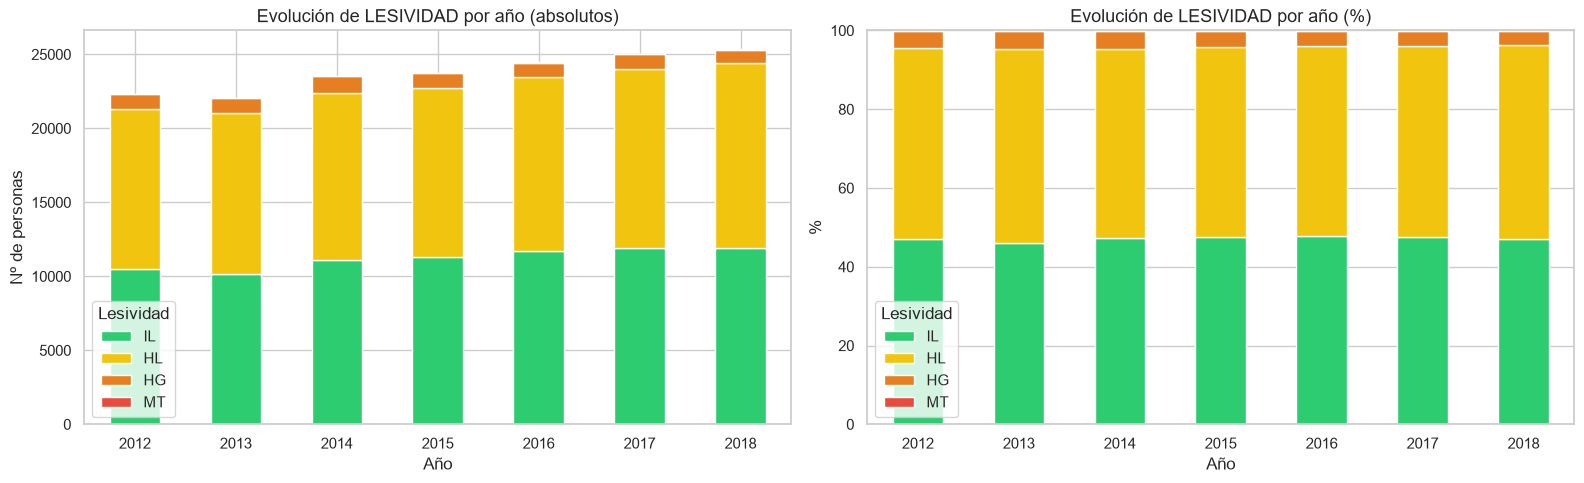

In [11]:
# Evolución de la gravedad por año
lesividad_año = (df_sin_na.groupby(['AÑO', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_año.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('Evolución de LESIVIDAD por año (absolutos)', fontsize=13)
axes[0].set_xlabel('Año'); axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad'); axes[0].tick_params(axis='x', rotation=0)

lesividad_año_pct = lesividad_año.div(lesividad_año.sum(axis=1), axis=0) * 100
lesividad_año_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Evolución de LESIVIDAD por año (%)', fontsize=13)
axes[1].set_xlabel('Año'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend(title='Lesividad'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/01c_lesividad_por_año.png', dpi=150)
plt.show()

In [ ]:
# Evolución de la tasa de gravedad por año (% HG+MT explícito por año)
tasa_grave_año = (df_sin_na.groupby('AÑO')['GRAVE']
                           .agg(['mean', 'count'])
                           .rename(columns={'mean': 'pct_grave', 'count': 'n_personas'})
                           .assign(pct_grave=lambda x: x['pct_grave'] * 100)
                           .reset_index())

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(tasa_grave_año['AÑO'], tasa_grave_año['n_personas'],
        color='steelblue', alpha=0.4, label='Nº personas (eje izq.)')
ax2.plot(tasa_grave_año['AÑO'], tasa_grave_año['pct_grave'],
         color='#e74c3c', marker='o', linewidth=2, markersize=8, label='% HG+MT (eje der.)')

for _, row in tasa_grave_año.iterrows():
    ax2.annotate(f"{row['pct_grave']:.1f}%", (row['AÑO'], row['pct_grave']),
                 textcoords='offset points', xytext=(0, 8), ha='center',
                 fontsize=9, color='#e74c3c', fontweight='bold')

ax1.set_xlabel('Año')
ax1.set_ylabel('Nº de personas implicadas', color='steelblue')
ax2.set_ylabel('% heridos graves o fallecidos (HG+MT)', color='#e74c3c')
ax1.set_title('Evolución anual: volumen y tasa de gravedad (2012-2018)', fontsize=14)
ax1.set_xticks(tasa_grave_año['AÑO'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/tendencia_gravedad_año.png', dpi=150)
plt.show()

print('Tasa de gravedad por año:')
print(tasa_grave_año[['AÑO', 'n_personas', 'pct_grave']].to_string(index=False))

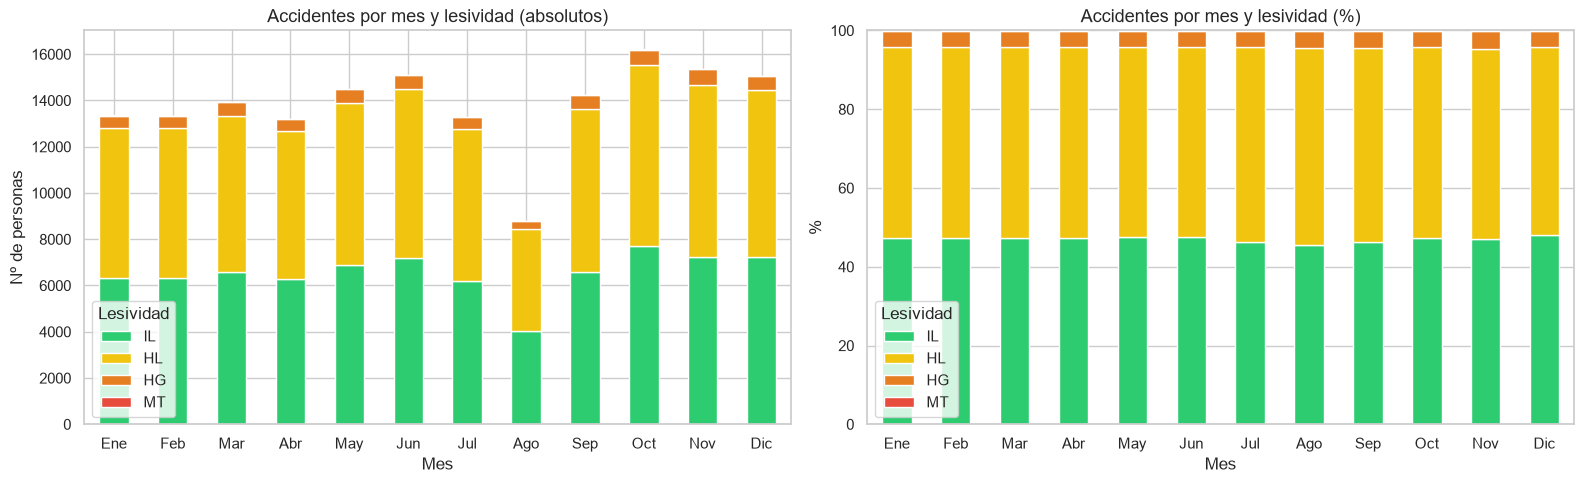

In [12]:
# Accidentes por mes con lesividad apilada
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
          7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

lesividad_mes = (df_sin_na.groupby(['MES', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_mes.index = lesividad_mes.index.map(meses)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_mes.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('Accidentes por mes y lesividad (absolutos)', fontsize=13)
axes[0].set_xlabel('Mes'); axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad'); axes[0].tick_params(axis='x', rotation=0)

lesividad_mes_pct = lesividad_mes.div(lesividad_mes.sum(axis=1), axis=0) * 100
lesividad_mes_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Accidentes por mes y lesividad (%)', fontsize=13)
axes[1].set_xlabel('Mes'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend(title='Lesividad'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/03_accidentes_por_mes.png', dpi=150)
plt.show()

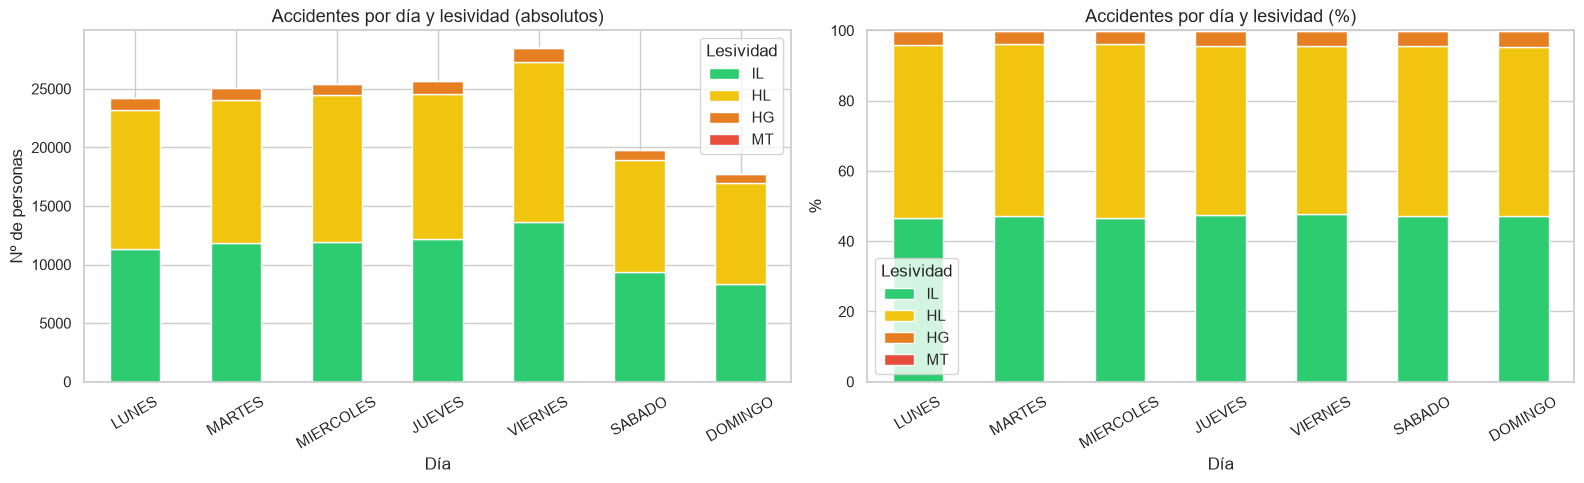

In [13]:
# Accidentes por día de la semana con lesividad apilada
orden_dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']

lesividad_dia = (df_sin_na.groupby(['DIA SEMANA', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(index=orden_dias, columns=ORDEN_LESIVIDAD, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_dia.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('Accidentes por día y lesividad (absolutos)', fontsize=13)
axes[0].set_xlabel('Día'); axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad'); axes[0].tick_params(axis='x', rotation=30)

lesividad_dia_pct = lesividad_dia.div(lesividad_dia.sum(axis=1), axis=0) * 100
lesividad_dia_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Accidentes por día y lesividad (%)', fontsize=13)
axes[1].set_xlabel('Día'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend(title='Lesividad'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/04_accidentes_por_dia.png', dpi=150)
plt.show()

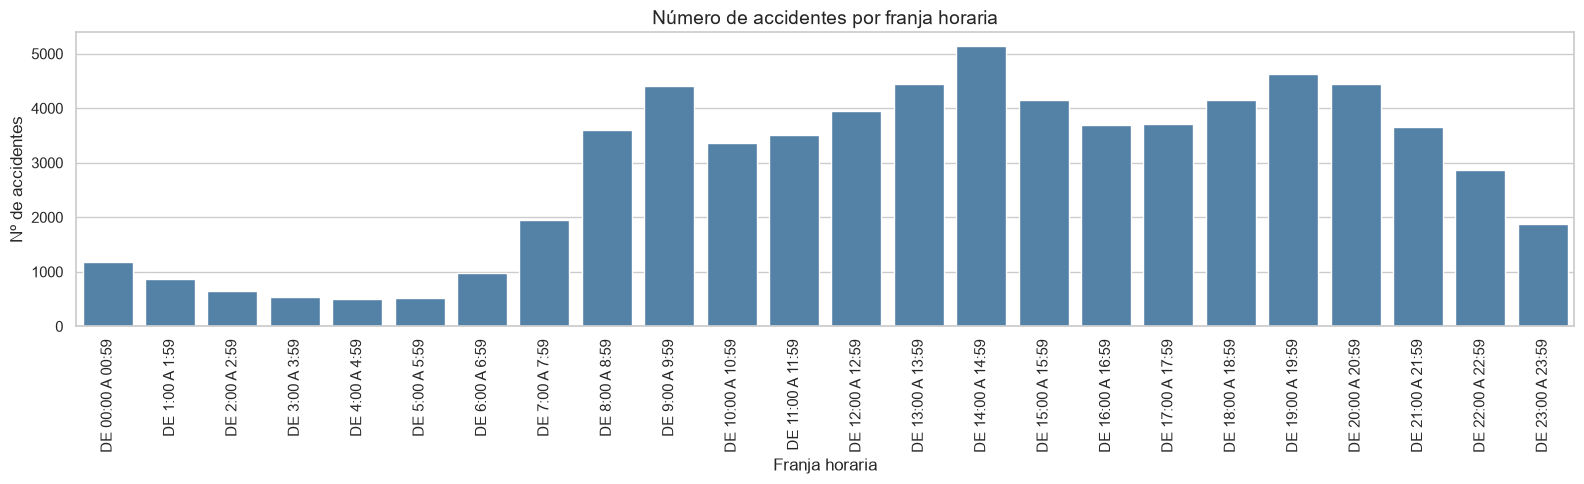

   RANGO HORARIO  Accidentes  Porcentaje (%)
DE 00:00 A 00:59        1176            1.71
  DE 1:00 A 1:59         872            1.27
  DE 2:00 A 2:59         654            0.95
  DE 3:00 A 3:59         537            0.78
  DE 4:00 A 4:59         501            0.73
  DE 5:00 A 5:59         520            0.76
  DE 6:00 A 6:59         985            1.43
  DE 7:00 A 7:59        1956            2.84
  DE 8:00 A 8:59        3600            5.23
  DE 9:00 A 9:59        4405            6.41
DE 10:00 A 10:59        3366            4.89
DE 11:00 A 11:59        3502            5.09
DE 12:00 A 12:59        3943            5.73
DE 13:00 A 13:59        4438            6.45
DE 14:00 A 14:59        5133            7.46
DE 15:00 A 15:59        4144            6.03
DE 16:00 A 16:59        3693            5.37
DE 17:00 A 17:59        3714            5.40
DE 18:00 A 18:59        4151            6.04
DE 19:00 A 19:59        4631            6.73
DE 20:00 A 20:59        4451            6.47
DE 21:00 A

In [14]:
# Franja horaria — orden cronológico (nivel accidente)
df_acc = df.drop_duplicates('Nº PARTE').copy()
df_acc['HORA'] = df_acc['RANGO HORARIO'].str.extract(r'(\d+)').astype(int)

accidentes_hora = (df_acc.groupby(['HORA', 'RANGO HORARIO']).size()
                         .reset_index(name='Accidentes')
                         .sort_values('HORA'))
accidentes_hora['Porcentaje (%)'] = (accidentes_hora['Accidentes'] / accidentes_hora['Accidentes'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(16, 5))
sns.barplot(data=accidentes_hora, x='RANGO HORARIO', y='Accidentes', ax=ax,
            order=accidentes_hora['RANGO HORARIO'], color='steelblue')
ax.set_title('Número de accidentes por franja horaria', fontsize=14)
ax.set_xlabel('Franja horaria'); ax.set_ylabel('Nº de accidentes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../figures/05_accidentes_por_hora.png', dpi=150)
plt.show()

print(accidentes_hora[['RANGO HORARIO', 'Accidentes', 'Porcentaje (%)']].to_string(index=False))

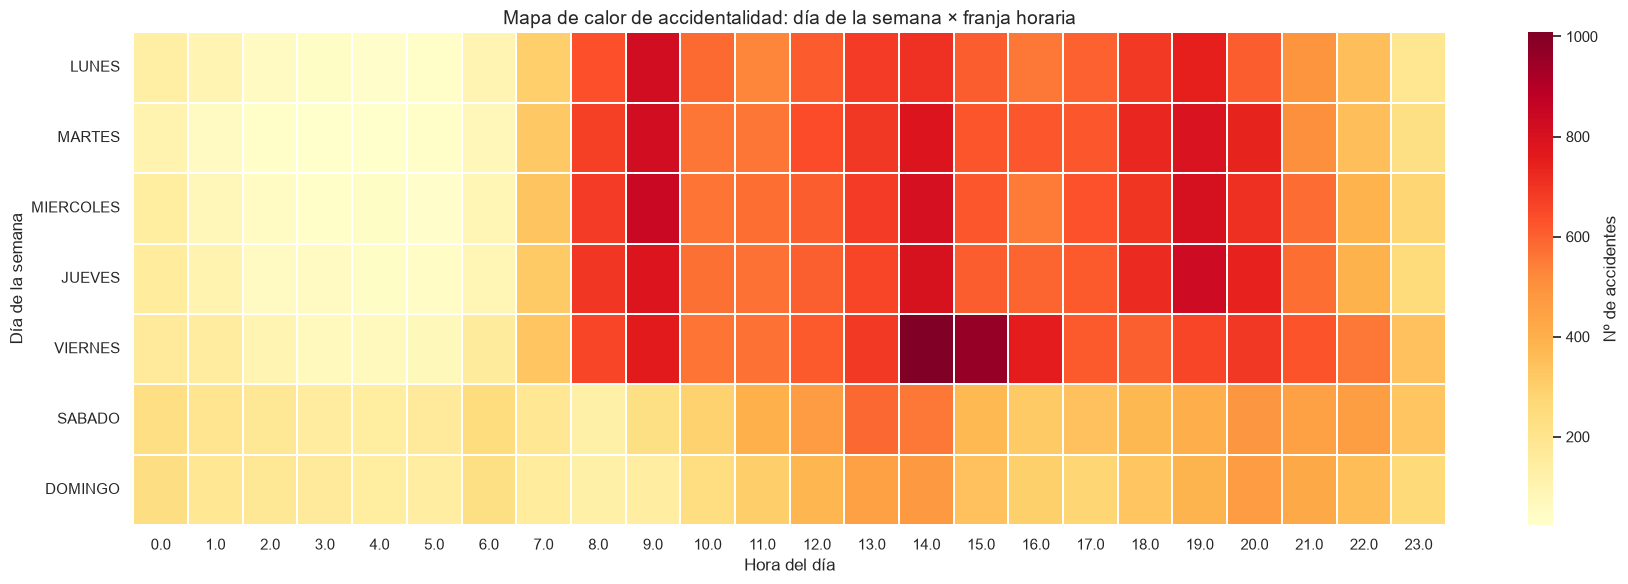

In [15]:
# Mapa de calor: hora × día de la semana (nivel accidente)
df_acc['HORA_NUM'] = df_acc['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)

heatmap_data = (df_acc.groupby(['DIA SEMANA', 'HORA_NUM'])
                      .size()
                      .unstack(fill_value=0)
                      .reindex(orden_dias, fill_value=0))

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Nº de accidentes'})
ax.set_title('Mapa de calor de accidentalidad: día de la semana × franja horaria', fontsize=14)
ax.set_xlabel('Hora del día'); ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig('../figures/05b_heatmap_dia_hora.png', dpi=150)
plt.show()

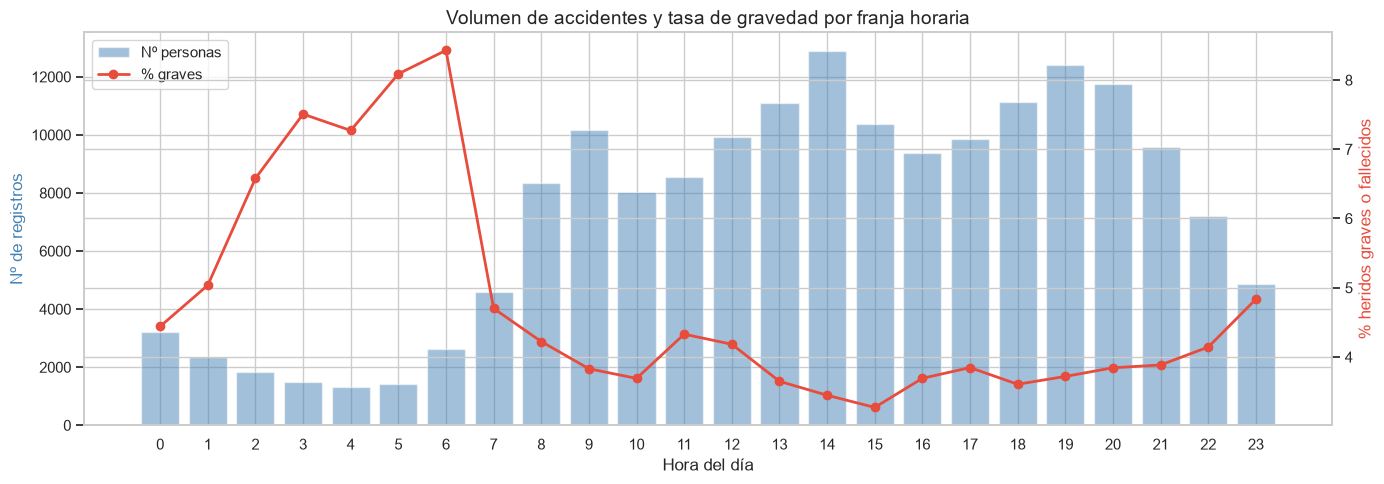

In [16]:
# Volumen de accidentes y tasa de gravedad por franja horaria
df['HORA']      = df['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)
df['GRAVE_tmp'] = df['LESIVIDAD'].isin(['HG', 'MT']).astype(float)
df.loc[df['LESIVIDAD'].isna(), 'GRAVE_tmp'] = float('nan')

accidentes_hora_n = df.groupby('HORA').size()
tasa_grave_hora   = df.groupby('HORA')['GRAVE_tmp'].mean() * 100

df.drop(columns=['HORA', 'GRAVE_tmp'], inplace=True)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(accidentes_hora_n.index, accidentes_hora_n.values, color='steelblue', alpha=0.5, label='Nº personas')
ax2.plot(tasa_grave_hora.index, tasa_grave_hora.values, color='#e74c3c',
         marker='o', linewidth=2, label='% graves')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Nº de registros', color='steelblue')
ax2.set_ylabel('% heridos graves o fallecidos', color='#e74c3c')
ax1.set_title('Volumen de accidentes y tasa de gravedad por franja horaria', fontsize=14)
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/14_gravedad_por_hora.png', dpi=150)
plt.show()

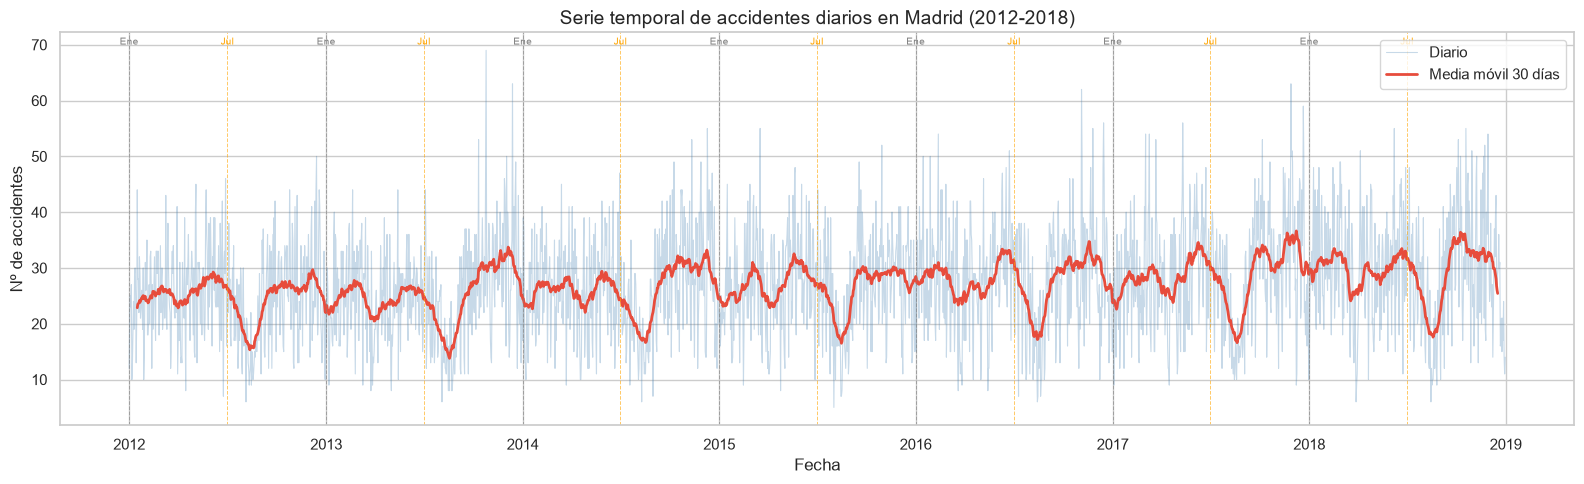

In [17]:
# Serie temporal: accidentes diarios con media móvil de 30 días
serie_temporal = (df_acc.groupby('FECHA').size().reset_index(name='Accidentes'))
serie_temporal['Media_30d'] = serie_temporal['Accidentes'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(serie_temporal['FECHA'], serie_temporal['Accidentes'],
        color='steelblue', alpha=0.3, linewidth=0.8, label='Diario')
ax.plot(serie_temporal['FECHA'], serie_temporal['Media_30d'],
        color='#e74c3c', linewidth=2, label='Media móvil 30 días')

for year in range(2012, 2019):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-07-01'), color='orange', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1]*0.97, 'Ene', fontsize=7, color='gray', ha='center')
    ax.text(pd.Timestamp(f'{year}-07-01'), ax.get_ylim()[1]*0.97, 'Jul', fontsize=7, color='orange', ha='center')

ax.set_title('Serie temporal de accidentes diarios en Madrid (2012-2018)', fontsize=14)
ax.set_xlabel('Fecha'); ax.set_ylabel('Nº de accidentes')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/05c_serie_temporal.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 3

> - Aunque el número de accidentes registrados va en aumento a lo largo de los años, la **proporción entre las diferentes clases de lesividad se mantiene estable**, lo que sugiere que la gravedad relativa no ha variado estructuralmente entre 2012 y 2018.
> - Los meses con mayor accidentalidad son **octubre, noviembre y junio**. Julio y agosto presentan la menor siniestralidad, probablemente por la reducción del tráfico en período vacacional.
> - Los días laborables concentran más accidentes que el fin de semana, coincidiendo con los desplazamientos al trabajo.
> - Las franjas horarias de mayor riesgo son las **horas punta** (9h, 14h, 17h). El heatmap confirma la concentración de accidentes en días laborables en esas franjas y destaca la alta siniestralidad del **viernes entre las 14h y las 16h**.
> - La serie temporal muestra una tendencia estructuralmente estable (entre 20 y 35 accidentes/día) con una **estacionalidad anual clara**: caída en verano y repunte en otoño.

---
## 4. Análisis geográfico

El distrito donde ocurre el accidente puede estar relacionado con factores estructurales como la densidad de tráfico, el tipo de vías o la velocidad permitida.

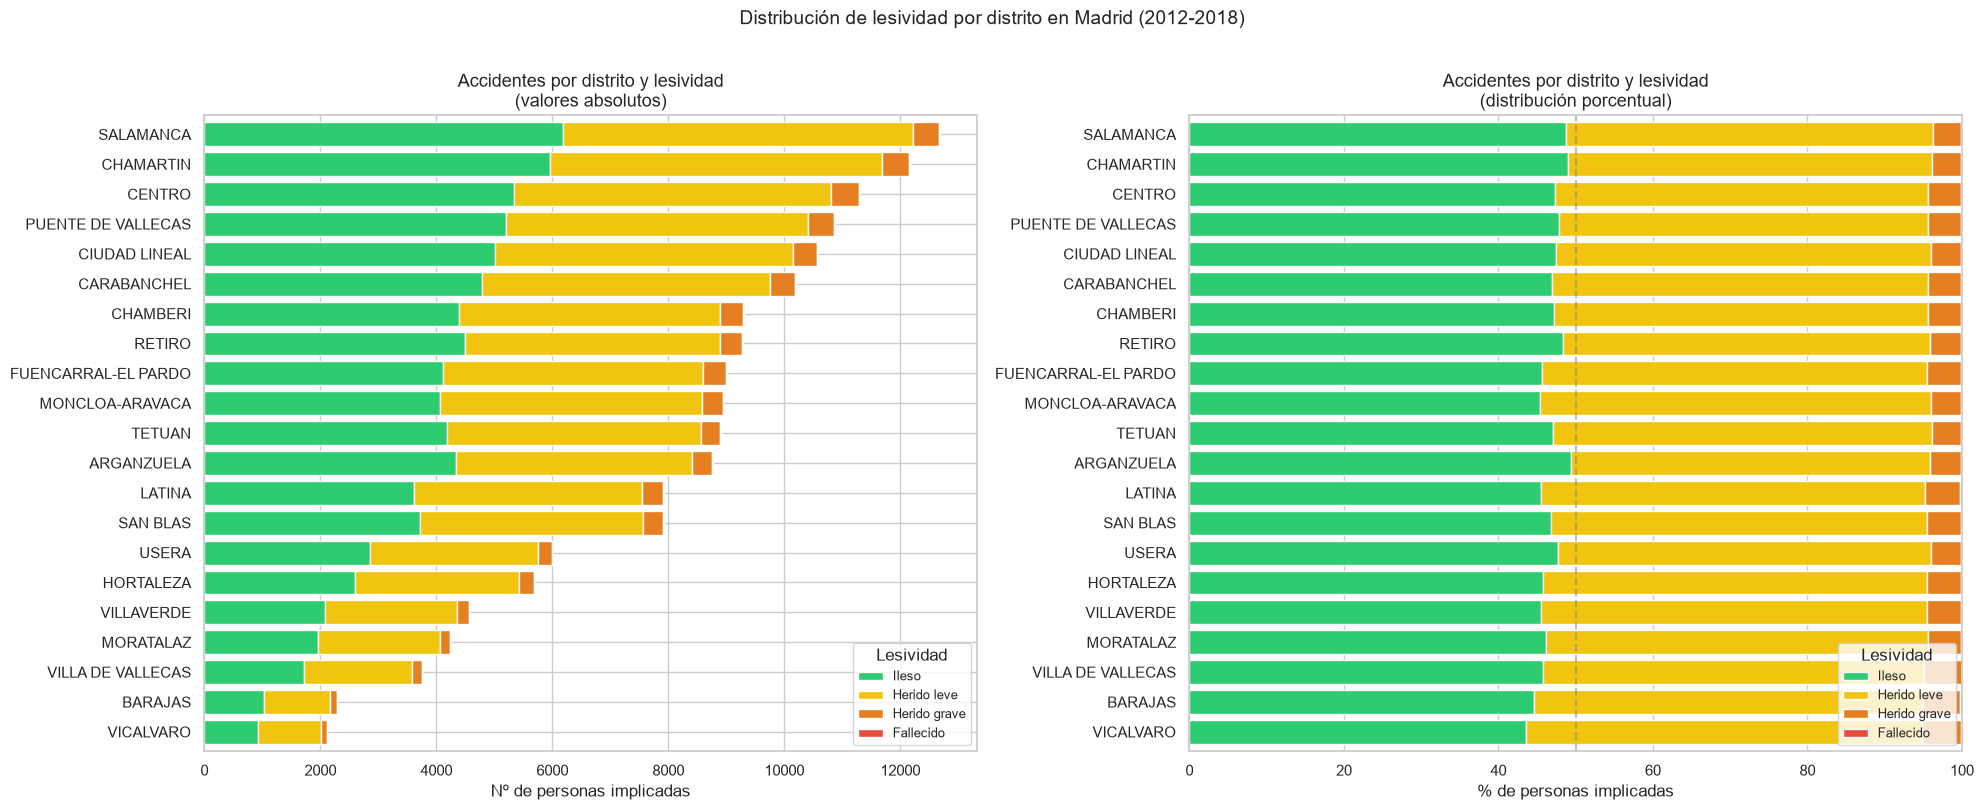

In [18]:
# Accidentes por distrito (nivel accidente)
accidentes_distrito = (df_acc.groupby('DISTRITO').size()
                             .sort_values(ascending=False)
                             .reset_index(name='Accidentes'))

# Lesividad apilada por distrito
lesividad_distrito = (df_sin_na.groupby(['DISTRITO', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_distrito['TOTAL'] = lesividad_distrito.sum(axis=1)
lesividad_distrito = lesividad_distrito.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_pct_dist = lesividad_distrito.div(lesividad_distrito.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

lesividad_distrito.plot(kind='barh', stacked=True, ax=axes[0],
                        color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], width=0.8)
axes[0].set_title('Accidentes por distrito y lesividad\n(valores absolutos)', fontsize=13)
axes[0].set_xlabel('Nº de personas implicadas'); axes[0].set_ylabel('')
axes[0].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               loc='lower right', fontsize=9)

lesividad_pct_dist.plot(kind='barh', stacked=True, ax=axes[1],
                         color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], width=0.8)
axes[1].set_title('Accidentes por distrito y lesividad\n(distribución porcentual)', fontsize=13)
axes[1].set_xlabel('% de personas implicadas'); axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].axvline(x=50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               loc='lower right', fontsize=9)

plt.suptitle('Distribución de lesividad por distrito en Madrid (2012-2018)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06e_lesividad_por_distrito.png', dpi=150, bbox_inches='tight')
plt.show()

A continuación, se estudia si el número de accidentes tiene relación con la población media por distrito en Madrid durante el periodo estudiado.

In [19]:
# Población media por distrito (media aritmética 2012-2018)
# Fuente: Ayuntamiento de Madrid - Estadística padronal municipal
# Documento disponible en data/raw/poblacion_distritos_madrid.pdf
poblacion_distritos = {
    'CENTRO': 134379, 'ARGANZUELA': 152309, 'RETIRO': 119387,
    'SALAMANCA': 145977, 'CHAMARTIN': 143899, 'TETUAN': 154592,
    'CHAMBERI': 138938, 'FUENCARRAL-EL PARDO': 238485, 'MONCLOA-ARAVACA': 116626,
    'LATINA': 233353, 'CARABANCHEL': 243663, 'USERA': 136491,
    'PUENTE DE VALLECAS': 229315, 'MORATALAZ': 94598, 'CIUDAD LINEAL': 213941,
    'HORTALEZA': 174369, 'VILLAVERDE': 144534, 'VILLA DE VALLECAS': 101411,
    'VICALVARO': 68875, 'SAN BLAS': 156145, 'BARAJAS': 46918
}
N_AÑOS = 7

accidentes_distrito['Poblacion']        = accidentes_distrito['DISTRITO'].map(poblacion_distritos)
accidentes_distrito['Accidentes_anuales'] = accidentes_distrito['Accidentes'] / N_AÑOS
accidentes_distrito['Tasa_por_100k']    = (accidentes_distrito['Accidentes_anuales'] /
                                            accidentes_distrito['Poblacion'] * 100_000).round(1)
accidentes_distrito = accidentes_distrito.sort_values('Tasa_por_100k', ascending=False)
print(accidentes_distrito[['DISTRITO', 'Accidentes', 'Poblacion', 'Tasa_por_100k']].to_string(index=False))

           DISTRITO  Accidentes  Poblacion  Tasa_por_100k
             CENTRO        4931     134379          524.2
          SALAMANCA        5274     145977          516.1
          CHAMARTIN        5022     143899          498.6
    MONCLOA-ARAVACA        3845     116626          471.0
             RETIRO        3665     119387          438.5
           CHAMBERI        4071     138938          418.6
             TETUAN        3820     154592          353.0
         ARGANZUELA        3476     152309          326.0
            BARAJAS        1043      46918          317.6
           SAN BLAS        3229     156145          295.4
      CIUDAD LINEAL        4341     213941          289.9
          MORATALAZ        1725      94598          260.5
 PUENTE DE VALLECAS        4091     229315          254.9
        CARABANCHEL        4079     243663          239.1
              USERA        2227     136491          233.1
FUENCARRAL-EL PARDO        3884     238485          232.7
  VILLA DE VAL

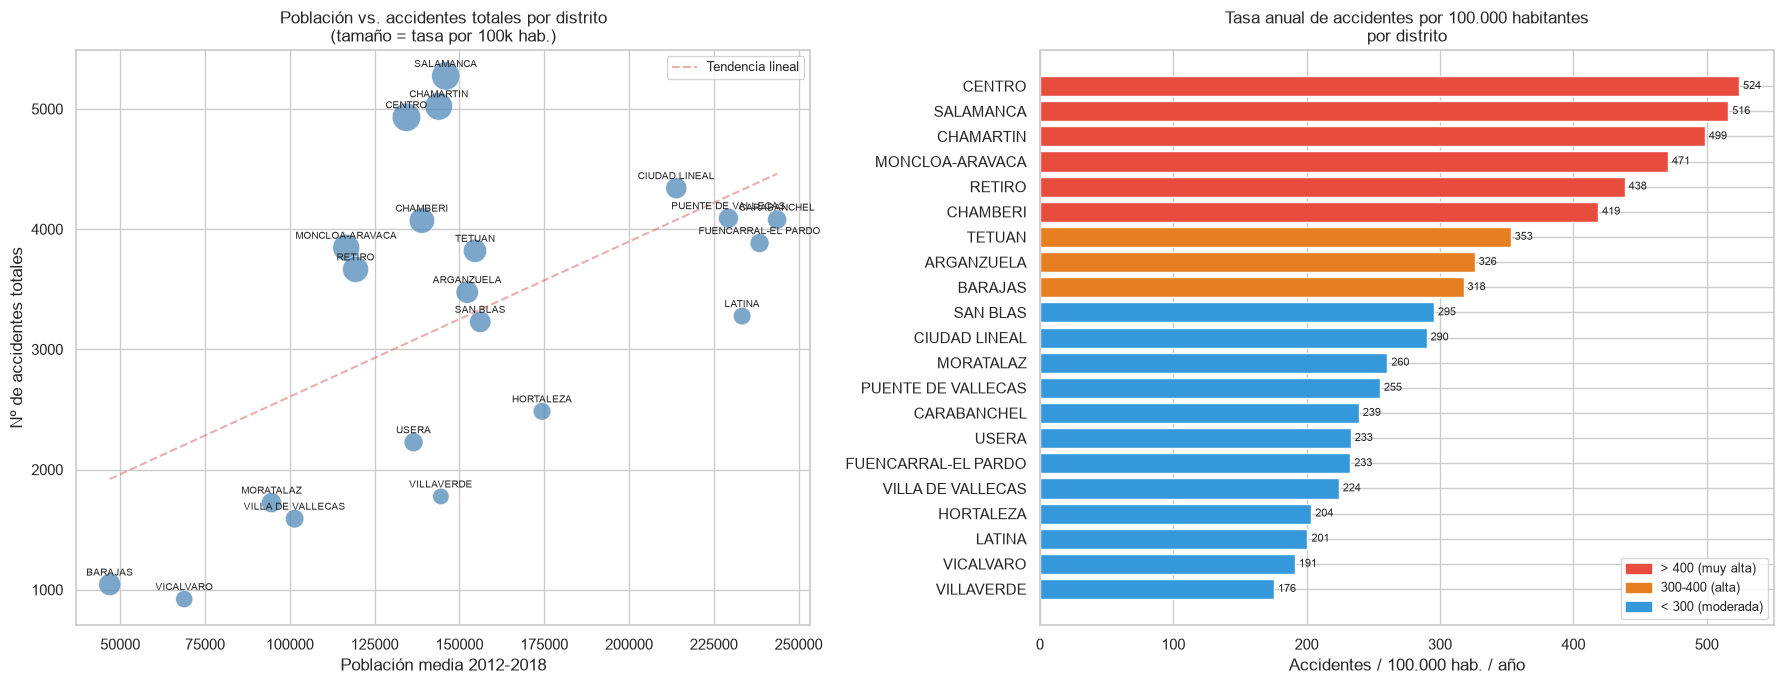

In [20]:
# Scatter: población vs accidentes + ranking por tasa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.scatter(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'],
           s=accidentes_distrito['Tasa_por_100k'] * 0.8,
           alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
for _, row in accidentes_distrito.iterrows():
    ax.annotate(row['DISTRITO'], (row['Poblacion'], row['Accidentes']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
z = np.polyfit(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'], 1)
p = np.poly1d(z)
x_line = np.linspace(accidentes_distrito['Poblacion'].min(), accidentes_distrito['Poblacion'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.5, label='Tendencia lineal')
ax.set_title('Población vs. accidentes totales por distrito\n(tamaño = tasa por 100k hab.)', fontsize=12)
ax.set_xlabel('Población media 2012-2018'); ax.set_ylabel('Nº de accidentes totales')
ax.legend(fontsize=9)

ax2 = axes[1]
datos_ordenados = accidentes_distrito.sort_values('Tasa_por_100k', ascending=True)
colores_tasa = ['#e74c3c' if t > 400 else '#e67e22' if t > 300 else '#3498db'
                for t in datos_ordenados['Tasa_por_100k']]
bars = ax2.barh(datos_ordenados['DISTRITO'], datos_ordenados['Tasa_por_100k'], color=colores_tasa)
ax2.set_title('Tasa anual de accidentes por 100.000 habitantes\npor distrito', fontsize=12)
ax2.set_xlabel('Accidentes / 100.000 hab. / año')
for bar, val in zip(bars, datos_ordenados['Tasa_por_100k']):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8)
from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='> 400 (muy alta)'),
           Patch(color='#e67e22', label='300-400 (alta)'),
           Patch(color='#3498db', label='< 300 (moderada)')]
ax2.legend(handles=leyenda, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/06c_scatter_poblacion_accidentes.png', dpi=150, bbox_inches='tight')
plt.show()

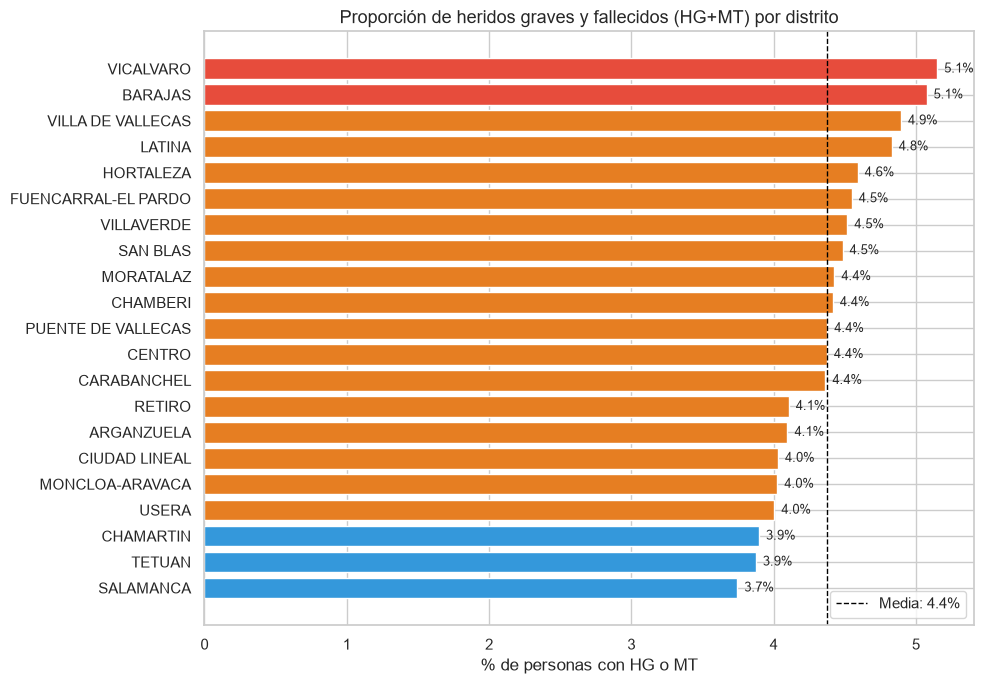

In [21]:
# Proporción de HG+MT por distrito
gravedad_distrito = (df_sin_na.groupby('DISTRITO')['GRAVE'].mean()
                               .mul(100).reset_index(name='Pct_HG_MT')
                               .sort_values('Pct_HG_MT', ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#e74c3c' if v > 5 else '#e67e22' if v > 4 else '#3498db'
           for v in gravedad_distrito['Pct_HG_MT']]
bars = ax.barh(gravedad_distrito['DISTRITO'], gravedad_distrito['Pct_HG_MT'], color=colores)
for bar, val in zip(bars, gravedad_distrito['Pct_HG_MT']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
media = gravedad_distrito['Pct_HG_MT'].mean()
ax.axvline(media, color='black', linestyle='--', linewidth=1, label=f'Media: {media:.1f}%')
ax.set_title('Proporción de heridos graves y fallecidos (HG+MT) por distrito', fontsize=13)
ax.set_xlabel('% de personas con HG o MT')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/06f_pct_graves_por_distrito.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 4

> - Una población más alta no se traduce directamente en más accidentes. **Salamanca, Chamartín y Centro** lideran en accidentalidad (tasa >490 accidentes/100k hab/año) sin ser los más poblados, lo que apunta al **tráfico de paso** como factor determinante.
> - Distritos periféricos con alta población (Latina, Carabanchel, Fuencarral) presentan tasas moderadas (<300).
> - Los distritos con mayor proporción de heridos graves o fallecidos (Villa de Vallecas, Vicálvaro, Barajas) **no coinciden** con los de mayor accidentalidad absoluta, lo que sugiere que el tipo de vía (carreteras de alta velocidad en periferia) influye más en la gravedad que el volumen.

---
## 5. Condiciones del accidente

Se analizan las variables relacionadas con el contexto del accidente: tipo, lugar, condiciones meteorológicas y estado del firme. Estas variables son candidatas clave para el modelo.

### Lugar del accidente

Se analiza brevemente el tipo de lugar o vía en que se producen los accidentes y su relación con la gravedad.

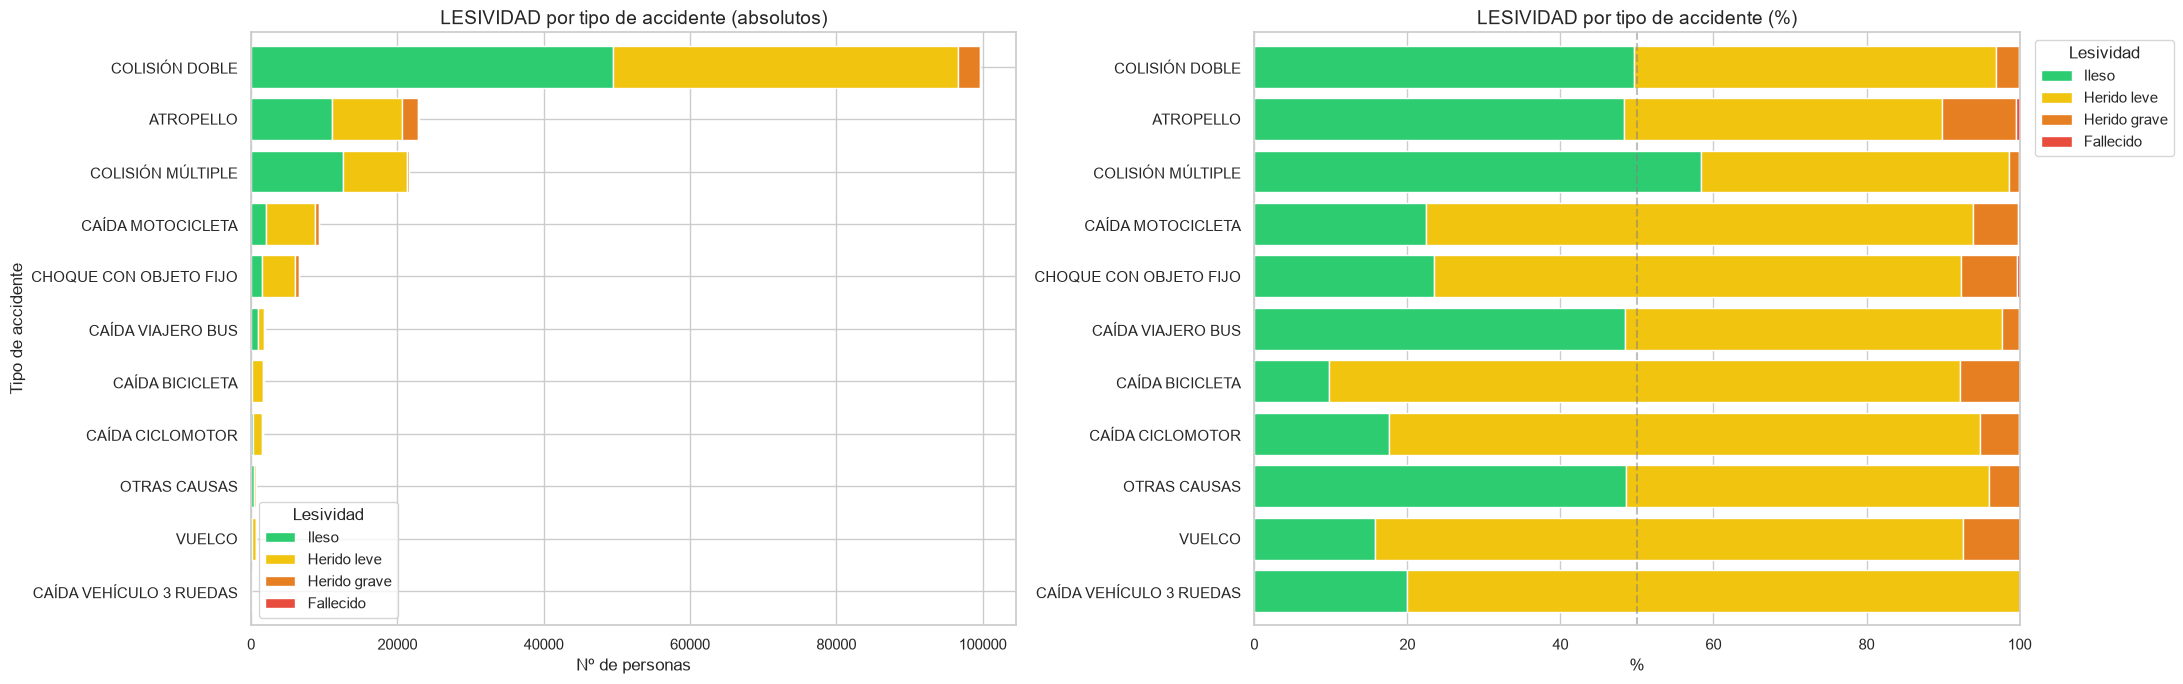

In [22]:
# Tipo de accidente (nivel accidente)
tipo_accidente = (df_acc.groupby('TIPO ACCIDENTE').size()
                        .sort_values(ascending=False)
                        .reset_index(name='Accidentes'))
tipo_accidente['Porcentaje (%)'] = (tipo_accidente['Accidentes'] / tipo_accidente['Accidentes'].sum() * 100).round(2)

# Tipo de accidente — absolutos apilados por lesividad + distribución %
lesividad_tipo_acc = (df_sin_na.groupby(['TIPO ACCIDENTE', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_tipo_acc['TOTAL'] = lesividad_tipo_acc.sum(axis=1)
lesividad_tipo_acc = lesividad_tipo_acc.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_tipo_acc_pct = lesividad_tipo_acc.div(lesividad_tipo_acc.sum(axis=1), axis=0) * 100

# Mismo orden para ambos gráficos
orden = lesividad_tipo_acc.index.tolist()

colores = [COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD]
labels  = ['Ileso', 'Herido leve', 'Herido grave', 'Fallecido']

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

lesividad_tipo_acc.reindex(orden).plot(kind='barh', stacked=True, ax=axes[0],
                                       color=colores, width=0.8, edgecolor='white')
axes[0].set_title('LESIVIDAD por tipo de accidente (absolutos)', fontsize=14)
axes[0].set_xlabel('Nº de personas'); axes[0].set_ylabel('Tipo de accidente')
axes[0].legend(title='Lesividad', labels=labels)

lesividad_tipo_acc_pct.reindex(orden).plot(kind='barh', stacked=True, ax=axes[1],
                                            color=colores, width=0.8, edgecolor='white')
axes[1].set_title('LESIVIDAD por tipo de accidente (%)', fontsize=14)
axes[1].set_xlabel('%'); axes[1].set_xlim(0, 100); axes[1].set_ylabel('')
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/07_tipo_accidente.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Construcción de lesividad_lugar y lesividad_lugar_pct
# (necesario para el análisis de Top 15 lugares con más accidentes graves)
lesividad_lugar = (df_sin_na.groupby(['LUGAR ACCIDENTE', 'LESIVIDAD'])
                             .size()
                             .unstack(fill_value=0)
                             .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_lugar['TOTAL'] = lesividad_lugar.sum(axis=1)
lesividad_lugar = lesividad_lugar.sort_values('TOTAL', ascending=False).drop(columns='TOTAL')
lesividad_lugar_pct = lesividad_lugar.div(lesividad_lugar.sum(axis=1), axis=0) * 100

print(f'Lugares únicos con accidentes registrados: {len(lesividad_lugar):,}')
print('\nTop 10 lugares por volumen de personas implicadas:')
print(lesividad_lugar.head(10))

In [23]:
# Top 15 lugares por nº de accidentes graves (HG + MT)
graves_cats = ['HG', 'MT']

lugar_graves = (lesividad_lugar[graves_cats]
                .sum(axis=1)
                .sort_values(ascending=False)
                .head(15))

top15_graves  = lugar_graves.index.tolist()
orden_graves  = top15_graves[::-1]

lesividad_graves_ord     = lesividad_lugar.reindex(orden_graves)
lesividad_graves_pct_ord = lesividad_lugar_pct.reindex(orden_graves)

colores = [COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD]
labels  = ['Ileso', 'Herido leve', 'Herido grave', 'Fallecido']

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

lesividad_graves_ord.plot(kind='barh', stacked=True, ax=axes[0], color=colores, width=0.8)
axes[0].set_title('Top 15 lugares con más accidentes graves\n(nº de víctimas)', fontsize=13)
axes[0].set_xlabel('Nº de víctimas'); axes[0].set_ylabel('')
axes[0].legend(title='Lesividad', labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left')

lesividad_graves_pct_ord.plot(kind='barh', stacked=True, ax=axes[1], color=colores, width=0.8)
axes[1].set_title('Distribución de lesividad\n(% por lugar, top 15 graves)', fontsize=13)
axes[1].set_xlabel('%'); axes[1].set_xlim(0, 100); axes[1].set_ylabel('')
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5)
axes[1].legend(title='Lesividad', labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Lugares con mayor concentración de accidentes graves (2012-2018)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/07e_top15_graves.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'lesividad_lugar' is not defined

In [ ]:
df['TIPO VIA'] = df['LUGAR ACCIDENTE'].str.extract(r'^(\w+)')
print(df['TIPO VIA'].value_counts().head(15))
df.drop(columns='TIPO VIA', inplace=True)

TIPO VIA
CALLE        96824
AVENIDA      36242
AUTOVIA      13960
PASEO        13495
PLAZA         4485
GLORIETA      2487
CARRETERA     2044
CAMINO         825
RONDA          740
CUESTA         683
ACCESO         330
COMPLEJO       313
PARQUE         293
GRAN           242
BULEVAR        213
Name: count, dtype: int64


LUGAR ACCIDENTE contiene información sobre el tipo de vía en su prefijo (CALLE, AVENIDA, AUTOPISTA, CARRETERA...). En la fase de feature engineering se extraerá esta información como nueva variable TIPO VIA, con el objetivo de capturar si el tipo de infraestructura vial influye en la gravedad del accidente.

### 5.2 Análisis de gravedad por tipo de vía

In [ ]:
# TIPO VIA: extracción, distribución y tasa de gravedad
df_sin_na['TIPO VIA'] = df_sin_na['LUGAR ACCIDENTE'].str.extract(r'^(\w+)')

# Agrupar tipos con menos de 500 casos en 'OTROS'
conteo_tv = df_sin_na['TIPO VIA'].value_counts()
tipos_principales = conteo_tv[conteo_tv >= 500].index.tolist()
df_sin_na['TIPO VIA'] = df_sin_na['TIPO VIA'].apply(
    lambda x: x if x in tipos_principales else 'OTROS'
)

# Tasa de gravedad por tipo de vía
tasa_grave_tv = (df_sin_na.groupby('TIPO VIA')['GRAVE']
                           .agg(['mean', 'count'])
                           .rename(columns={'mean': 'pct_grave', 'count': 'n_personas'})
                           .assign(pct_grave=lambda x: x['pct_grave'] * 100)
                           .sort_values('pct_grave', ascending=True))

media_global_tv = df_sin_na['GRAVE'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volumen
orden_vol = tasa_grave_tv.sort_values('n_personas')
bars0 = axes[0].barh(orden_vol.index, orden_vol['n_personas'],
                      color='steelblue', edgecolor='white')
for bar, val in zip(bars0, orden_vol['n_personas']):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}', va='center', fontsize=8)
axes[0].set_title('Nº de personas implicadas por tipo de vía', fontsize=13)
axes[0].set_xlabel('Nº de personas')

# Tasa de gravedad
colores_tv = ['#e74c3c' if v > media_global_tv * 1.5
               else '#e67e22' if v > media_global_tv
               else '#3498db'
               for v in tasa_grave_tv['pct_grave']]
bars1 = axes[1].barh(tasa_grave_tv.index, tasa_grave_tv['pct_grave'],
                      color=colores_tv, edgecolor='white')
for bar, val in zip(bars1, tasa_grave_tv['pct_grave']):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].axvline(media_global_tv, color='black', linestyle='--', linewidth=1,
                label=f'Media global: {media_global_tv:.1f}%')

from matplotlib.patches import Patch
leyenda_tv = [
    Patch(color='#e74c3c', label=f'Alta (> {media_global_tv * 1.5:.1f}%)'),
    Patch(color='#e67e22', label=f'Moderada ({media_global_tv:.1f}%–{media_global_tv * 1.5:.1f}%)'),
    Patch(color='#3498db', label=f'Baja (< {media_global_tv:.1f}%)')
]
axes[1].legend(handles=leyenda_tv, loc='lower right', fontsize=9)
axes[1].set_title('% de heridos graves/fallecidos por tipo de vía', fontsize=13)
axes[1].set_xlabel('% HG+MT')

plt.suptitle('Accidentalidad y gravedad por tipo de vía (2012-2018)', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/tipo_via_gravedad.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTasa de gravedad por tipo de vía (de mayor a menor):')
print(tasa_grave_tv.sort_values('pct_grave', ascending=False)[
      ['n_personas', 'pct_grave']].round(2).to_string())

> **Resumen Tipo de Vía:** Las carreteras, autovías y accesos presentan las tasas de gravedad más altas, coherente con las mayores velocidades permitidas en vías interurbanas. Las calles y avenidas urbanas concentran el mayor volumen de accidentes pero con gravedad relativa más baja. La variable `TIPO VIA` (extraída de `LUGAR ACCIDENTE` en preprocessing) tiene potencial predictivo diferencial para el modelo.

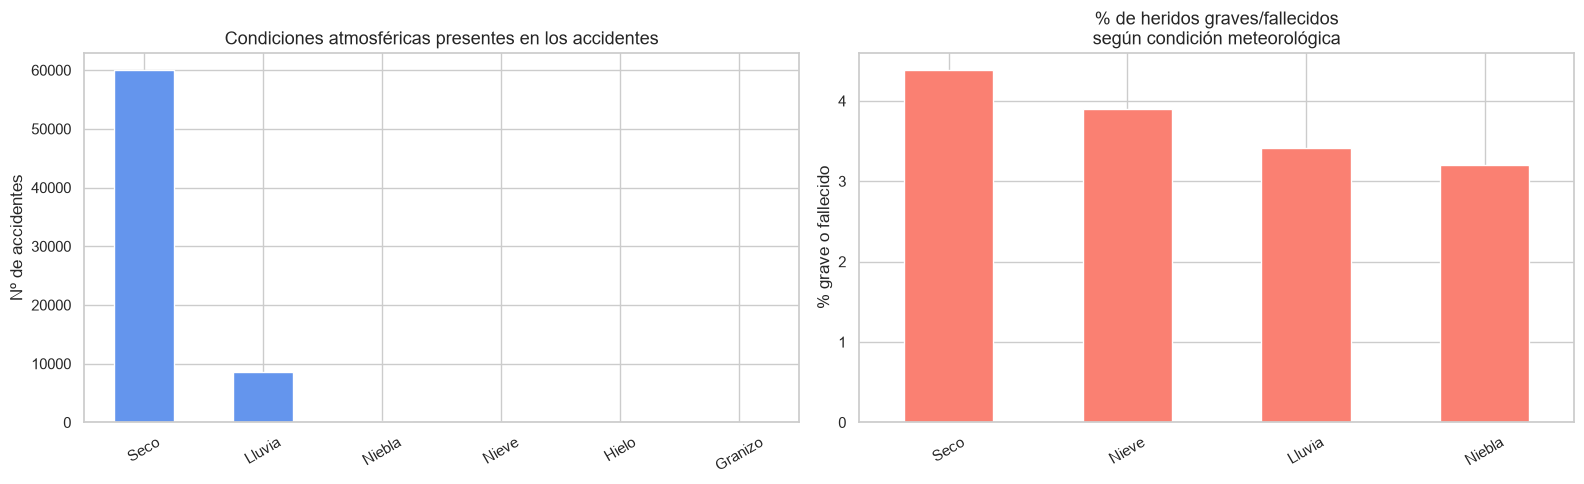

        Nº accidentes Porcentaje (%)  % graves
Granizo             9           0.01       NaN
Hielo              65           0.09       NaN
Lluvia           8535          12.41      3.41
Niebla            188           0.27      3.20
Nieve              68            0.1      3.90
Seco            59975          87.21      4.38


In [ ]:
# Condiciones meteorológicas (CPFA) — frecuencia y tasa de gravedad
cols_cpfa = [c for c in df.columns if c.startswith('CPFA')]

cpfa_df   = df_acc[cols_cpfa].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cpfa_counts = cpfa_df.sum().sort_values(ascending=False)

tasas_graves_cpfa = {}
for col in cols_cpfa:
    nombre = col.replace('CPFA ', '')
    mask = df_sin_na[col].str.strip() == 'SI'
    if mask.sum() > 100:
        tasas_graves_cpfa[nombre] = df_sin_na.loc[mask, 'GRAVE'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cpfa_counts.plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Condiciones atmosféricas presentes en los accidentes', fontsize=13)
axes[0].set_xticklabels([c.replace('CPFA ', '') for c in cpfa_counts.index], rotation=30)
axes[0].set_ylabel('Nº de accidentes')

pd.Series(tasas_graves_cpfa).sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('% de heridos graves/fallecidos\nsegún condición meteorológica', fontsize=13)
axes[1].set_ylabel('% grave o fallecido'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/08_condiciones_atmosfericas.png', dpi=150)
plt.show()

tabla_cpfa = pd.DataFrame({
    'Nº accidentes': cpfa_counts,
    'Porcentaje (%)': (cpfa_counts / len(df_acc) * 100).round(2),
    '% graves':       pd.Series({f'CPFA {k}': v for k, v in tasas_graves_cpfa.items()}).round(2)
})
tabla_cpfa.index = [i.replace('CPFA ', '') for i in tabla_cpfa.index]
print(tabla_cpfa.to_string())

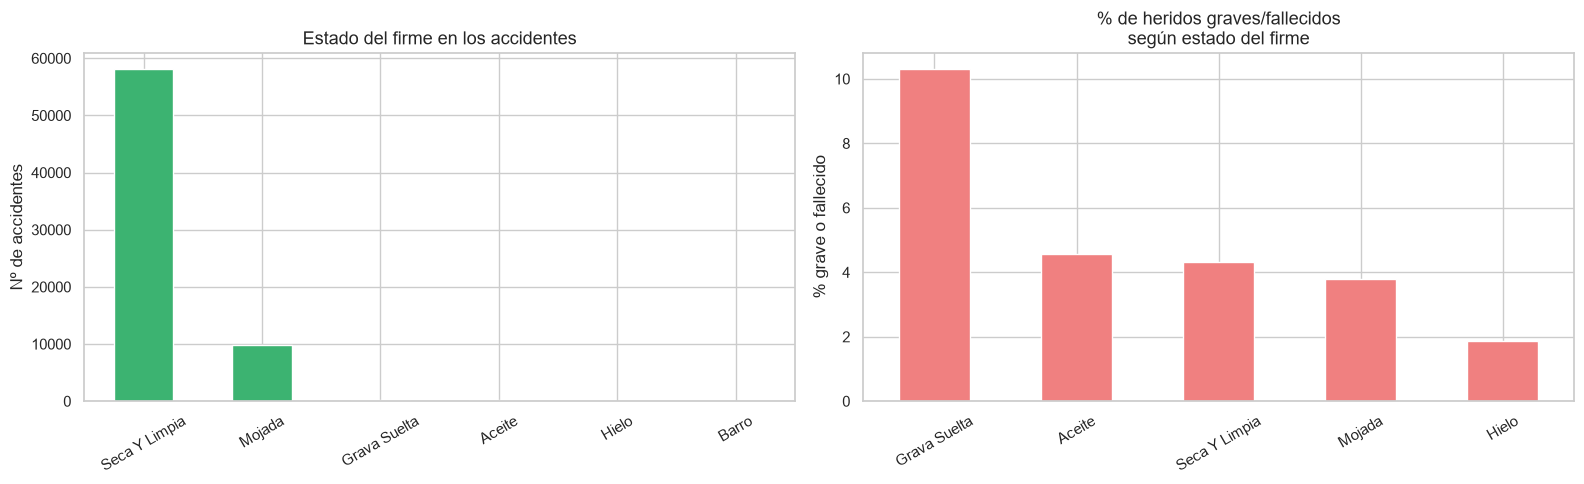

              Nº accidentes Porcentaje (%)  % graves
Aceite                  260           0.38      4.57
Barro                    59           0.09       NaN
Grava Suelta            273            0.4     10.30
Hielo                   102           0.15      1.85
Mojada                 9828          14.29      3.78
Seca Y Limpia         58073          84.44      4.32


In [ ]:
# Estado del firme (CPSV) — frecuencia y tasa de gravedad
cols_cpsv = [c for c in df.columns if c.startswith('CPSV')]

cpsv_df     = df_acc[cols_cpsv].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cpsv_counts = cpsv_df.sum().sort_values(ascending=False)

tasas_graves_cpsv = {}
for col in cols_cpsv:
    nombre = col.replace('CPSV ', '')
    mask = df_sin_na[col].str.strip() == 'SI'
    if mask.sum() > 100:
        tasas_graves_cpsv[nombre] = df_sin_na.loc[mask, 'GRAVE'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cpsv_counts.plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Estado del firme en los accidentes', fontsize=13)
axes[0].set_xticklabels([c.replace('CPSV ', '') for c in cpsv_counts.index], rotation=30)
axes[0].set_ylabel('Nº de accidentes')

pd.Series(tasas_graves_cpsv).sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('% de heridos graves/fallecidos\nsegún estado del firme', fontsize=13)
axes[1].set_ylabel('% grave o fallecido'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/09_estado_firme.png', dpi=150)
plt.show()

tabla_cpsv = pd.DataFrame({
    'Nº accidentes': cpsv_counts,
    'Porcentaje (%)': (cpsv_counts / len(df_acc) * 100).round(2),
    '% graves':       pd.Series({f'CPSV {k}': v for k, v in tasas_graves_cpsv.items()}).round(2)
})
tabla_cpsv.index = [i.replace('CPSV ', '') for i in tabla_cpsv.index]
print(tabla_cpsv.to_string())

### 📝 Resumen — Sección 5

> - El tipo de accidente más frecuente es **colisión doble** (>50%), seguido de atropello y caída de motocicleta. Sin embargo, el tipo con mayor proporción de heridos graves es **caída de bicicleta**.
> - La condición meteorológica predominante es **seco**, coherente con el clima de Madrid. No obstante, la tasa de graves es significativamente mayor cuando nieva o llueve.
> - El estado del firme con mayor tasa de accidentes graves es **grava suelta y aceite en la vía**, aunque son situaciones poco frecuentes. La gran mayoría de accidentes ocurren en firme seco y limpio.
> - La variable `LUGAR ACCIDENTE` muestra que los accidentes más graves ocurren en vías de mayor velocidad, mientras que las intersecciones y cruces concentran el mayor volumen de accidentes.

---
## 6. Análisis multivariante y asociación estadística

Se estudian las relaciones entre variables categóricas clave y `accidente_grave` mediante:
1. **V de Cramér**: medida de asociación entre variables categóricas (0 = sin asociación, 1 = perfecta).
2. **Test chi-cuadrado**: contraste de independencia entre cada predictora y la variable objetivo.
> **Nota sobre el nivel de análisis:** Algunas variables incluidas en este análisis (`TIPO PERSONA`, `SEXO`, `Tramo Edad`, `Tipo Vehiculo`) son atributos de persona, no de accidente. Su inclusión es intencional: se analiza su asociación con la gravedad a nivel persona (sobre `df_sin_na`) para cuantificar su relevancia predictiva y orientar la estrategia de agregación en preprocessing (ej. presencia de peatón, grupo de edad máxima, tipo de vehículo implicado).

In [ ]:
# Función para calcular la V de Cramér
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)

# Variables categóricas clave (excluir identificadores y fecha)
vars_categoricas = ['TIPO ACCIDENTE', 'DIA SEMANA', 'RANGO HORARIO', 'DISTRITO',
                    'TIPO PERSONA', 'SEXO', 'Tramo Edad', 'Tipo Vehiculo', 'LUGAR ACCIDENTE']

# Filtrar a las que existen en df_sin_na
vars_categoricas = [v for v in vars_categoricas if v in df_sin_na.columns]

# Calcular V de Cramér de cada variable con LESIVIDAD y con GRAVE
print('V de Cramér con la variable objetivo:')
print(f'{"Variable":<25} {"V Cramér vs LESIVIDAD":>22} {"V Cramér vs GRAVE":>20}')
print('-' * 70)

resultados = []
for var in vars_categoricas:
    mask = df_sin_na[var].notna() & df_sin_na['LESIVIDAD'].notna()
    v_les = cramers_v(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'LESIVIDAD'])
    v_gra = cramers_v(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'GRAVE'].astype(str))
    resultados.append({'Variable': var, 'V_Lesividad': v_les, 'V_Grave': v_gra})
    print(f'{var:<25} {v_les:>22.4f} {v_gra:>20.4f}')

df_cramer = pd.DataFrame(resultados).sort_values('V_Grave', ascending=False)

V de Cramér con la variable objetivo:
Variable                   V Cramér vs LESIVIDAD    V Cramér vs GRAVE
----------------------------------------------------------------------
TIPO ACCIDENTE                            0.1388               0.1362
DIA SEMANA                                0.0079               0.0117
RANGO HORARIO                             0.0367               0.0503
DISTRITO                                  0.0144               0.0122
TIPO PERSONA                              0.2167               0.2154
SEXO                                      0.0802               0.0242
Tramo Edad                                0.1118               0.0859
Tipo Vehiculo                             0.3219               0.2721
LUGAR ACCIDENTE                           0.0630               0.1918


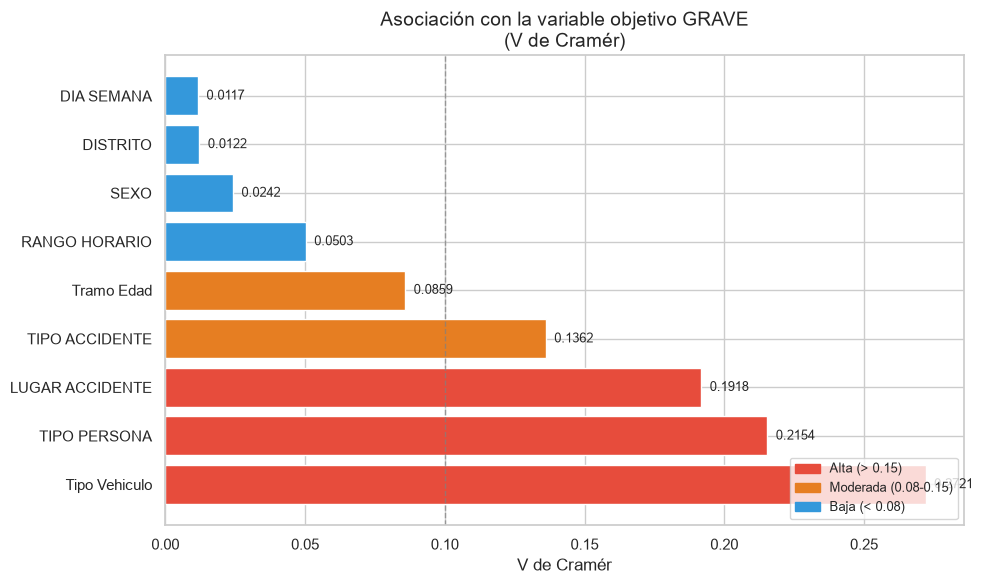

In [ ]:
# Visualización: ranking de V de Cramér con GRAVE
fig, ax = plt.subplots(figsize=(10, 6))

colores_cv = ['#e74c3c' if v > 0.15 else '#e67e22' if v > 0.08 else '#3498db'
              for v in df_cramer['V_Grave']]
bars = ax.barh(df_cramer['Variable'], df_cramer['V_Grave'], color=colores_cv)

for bar, val in zip(bars, df_cramer['V_Grave']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(0.10, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Umbral moderado (0.10)')
ax.set_title('Asociación con la variable objetivo GRAVE\n(V de Cramér)', fontsize=14)
ax.set_xlabel('V de Cramér')
ax.legend()

from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='Alta (> 0.15)'),
           Patch(color='#e67e22', label='Moderada (0.08-0.15)'),
           Patch(color='#3498db', label='Baja (< 0.08)')]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/16_cramer_v_asociacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tests chi-cuadrado: independencia entre cada variable y GRAVE
print(f'Test chi-cuadrado (H0: independencia entre variable y GRAVE)')
print(f'{"Variable":<25} {"chi2":>12} {"p-valor":>15} {"Sig.":>6}')
print('-' * 65)

for _, row in df_cramer.iterrows():
    var = row['Variable']
    mask = df_sin_na[var].notna() & df_sin_na['GRAVE'].notna()
    ct = pd.crosstab(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'GRAVE'])
    chi2_val, p_val, _, _ = chi2_contingency(ct)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f'{var:<25} {chi2_val:>12.1f} {p_val:>15.2e} {sig:>6}')

print('\nSignificancia: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = no significativo')

Test chi-cuadrado (H0: independencia entre variable y GRAVE)
Variable                          chi2         p-valor   Sig.
-----------------------------------------------------------------
Tipo Vehiculo                  12336.3        0.00e+00    ***
TIPO PERSONA                    7729.7        0.00e+00    ***
LUGAR ACCIDENTE                20082.3       4.94e-230    ***
TIPO ACCIDENTE                  3096.7        0.00e+00    ***
Tramo Edad                      1244.7       3.47e-254    ***
RANGO HORARIO                    443.9        1.55e-79    ***
SEXO                              99.8        2.12e-22    ***
DISTRITO                          44.9        1.16e-03     **
DIA SEMANA                        28.9        6.45e-05    ***

Significancia: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = no significativo


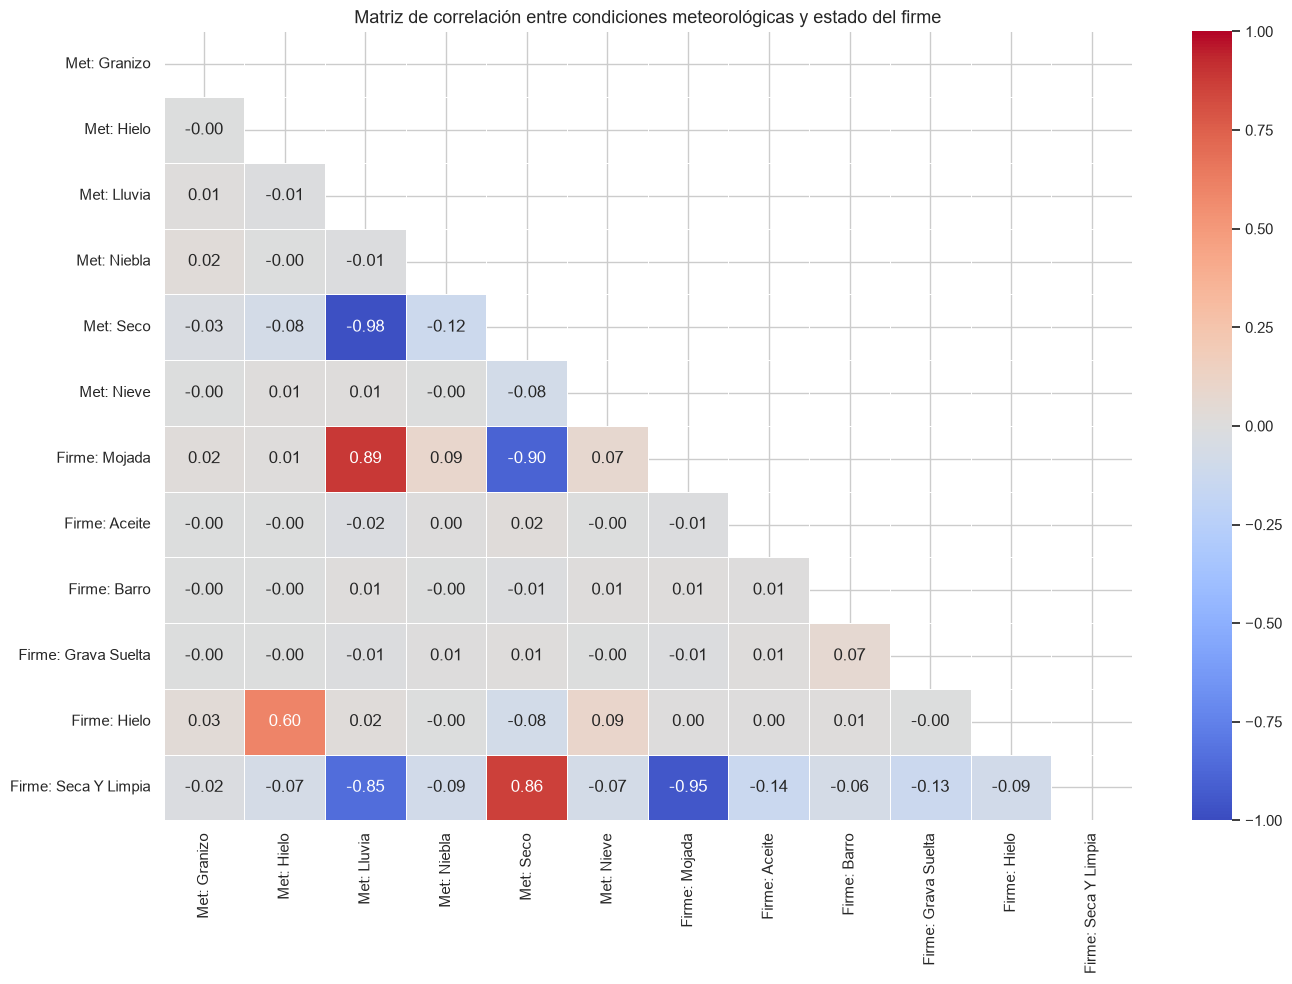

In [ ]:
# Heatmap de co-ocurrencia entre condiciones CPFA y CPSV (nivel accidente)
cols_cond = [c for c in df_acc.columns if c.startswith('CPFA') or c.startswith('CPSV')]

# Convertir a binario
cond_binary = df_acc[cols_cond].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cond_binary.columns = [c.replace('CPFA ', 'Met: ').replace('CPSV ', 'Firme: ') for c in cond_binary.columns]

corr_cond = cond_binary.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask_tri = np.triu(np.ones_like(corr_cond, dtype=bool))
sns.heatmap(corr_cond, mask=mask_tri, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación entre condiciones meteorológicas y estado del firme', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/17_heatmap_condiciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Análisis de interacciones entre variables clave

Se estudian tres interacciones clave mediante heatmaps de tasa de gravedad (% HG+MT):
1. **Tipo de persona × Tipo de accidente**: ¿varía la gravedad del mismo tipo de accidente según el perfil de la víctima?
2. **Día de la semana × Franja horaria**: ¿difiere la gravedad —no solo el volumen— según el momento del día y la semana?
3. **Tipo de vehículo × Grupo de edad**: ¿actúa la edad como factor modificador del riesgo según el tipo de vehículo?

In [ ]:
# Interacción 1: TIPO PERSONA × TIPO ACCIDENTE — % HG+MT
pivot_int1 = (df_sin_na.groupby(['TIPO PERSONA', 'TIPO ACCIDENTE'])['GRAVE']
              .agg(['mean', 'count'])
              .reset_index())
pivot_int1.columns = ['TIPO PERSONA', 'TIPO ACCIDENTE', 'pct_grave', 'n']
pivot_int1['pct_grave'] *= 100
pivot_int1 = pivot_int1[pivot_int1['n'] >= 50]  # solo combinaciones con suficientes casos

heatmap_int1 = pivot_int1.pivot_table(
    index='TIPO PERSONA', columns='TIPO ACCIDENTE', values='pct_grave'
)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(heatmap_int1, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% HG+MT'}, annot_kws={'size': 9})
ax.set_title(
    '% de heridos graves/fallecidos: TIPO PERSONA × TIPO ACCIDENTE\n'
    '(solo combinaciones con ≥ 50 registros)', fontsize=13)
ax.set_xlabel('Tipo de accidente'); ax.set_ylabel('Tipo de persona')
plt.tight_layout()
plt.savefig('../figures/interaccion_persona_accidente.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Interacción 2: DÍA SEMANA × FRANJA HORARIA — tasa de gravedad (% HG+MT)
# Complementa el heatmap de volumen de la Sección 3
df_sin_na['HORA_NUM'] = df_sin_na['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)

heatmap_grave_diahora = (
    df_sin_na.groupby(['DIA SEMANA', 'HORA_NUM'])['GRAVE']
             .mean()
             .unstack(fill_value=np.nan)
             .reindex(orden_dias, fill_value=np.nan) * 100
)

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(heatmap_grave_diahora, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': '% HG+MT'}, annot=False)
ax.set_title(
    'Tasa de gravedad (% HG+MT): día de la semana × franja horaria\n'
    '(complementa el heatmap de volumen de la Sección 3)', fontsize=13)
ax.set_xlabel('Hora del día'); ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig('../figures/heatmap_gravedad_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()

df_sin_na.drop(columns=['HORA_NUM'], inplace=True, errors='ignore')

In [ ]:
# Interacción 3: Tipo de vehículo × Grupo de edad — % HG+MT
grupos_edad_map = {
    'DE 0 A 5 AÑOS': '<18',  'DE 6 A 9 AÑOS': '<18',  'DE 10 A 14 AÑOS': '<18',
    'DE 15 A 17 AÑOS': '<18', 'DE 18 A 20 AÑOS': '18-24', 'DE 21 A 24 AÑOS': '18-24',
    'DE 25 A 29 AÑOS': '25-34', 'DE 30 A 34 ANOS': '25-34',
    'DE 35 A 39 AÑOS': '35-44', 'DE 40 A 44 AÑOS': '35-44',
    'DE 45 A 49 AÑOS': '45-54', 'DE 50 A 54 AÑOS': '45-54',
    'DE 55 A 59 AÑOS': '55-64', 'DE 60 A 64 AÑOS': '55-64',
    'DE 65 A 69 AÑOS': '65+',   'DE 70 A 74 AÑOS': '65+', 'DE MAS DE 74 AÑOS': '65+'
}
orden_grupos_edad = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
vehiculos_int3 = ['TURISMO', 'MOTOCICLETA', 'CICLOMOTOR', 'BICICLETA', 'FURGONETA']

df_int3 = df_sin_na.dropna(subset=['Tramo Edad', 'Tipo Vehiculo']).copy()
df_int3['Grupo Edad'] = df_int3['Tramo Edad'].map(grupos_edad_map)
df_int3 = df_int3[df_int3['Tipo Vehiculo'].isin(vehiculos_int3)].dropna(subset=['Grupo Edad'])

pivot_int3 = (df_int3.groupby(['Tipo Vehiculo', 'Grupo Edad'])['GRAVE']
              .agg(['mean', 'count'])
              .reset_index())
pivot_int3.columns = ['Tipo Vehiculo', 'Grupo Edad', 'pct_grave', 'n']
pivot_int3 = pivot_int3[pivot_int3['n'] >= 30]
pivot_int3['pct_grave'] *= 100

heatmap_int3 = (pivot_int3.pivot_table(
                    index='Tipo Vehiculo', columns='Grupo Edad', values='pct_grave')
                           .reindex(columns=orden_grupos_edad))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_int3, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% HG+MT'})
ax.set_title(
    '% de heridos graves/fallecidos: Tipo de vehículo × Grupo de edad\n'
    '(solo combinaciones con ≥ 30 registros)', fontsize=13)
ax.set_xlabel('Grupo de edad'); ax.set_ylabel('Tipo de vehículo')
plt.tight_layout()
plt.savefig('../figures/interaccion_vehiculo_edad.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Resumen — Sección 6.2 (Interacciones)

> - **Persona × Tipo accidente:** Los peatones atropellados presentan la tasa de HG+MT más alta. La caída de bicicleta tiene gravedad muy diferente según el tipo de implicado.
> - **Día × Hora (gravedad):** La madrugada del viernes-sábado y sábado-domingo presenta tasas de gravedad más altas a pesar del menor volumen, con mayor riesgo relativo en horas de baja circulación.
> - **Vehículo × Edad:** Los mayores de 65 años muestran mayor gravedad independientemente del vehículo. Los ciclistas jóvenes (<18) tienen tasas de gravedad elevadas. Estas interacciones sugieren que la combinación edad + vehículo puede tener mayor capacidad predictiva que cada variable por separado.

### 📝 Resumen — Sección 6

> - La **V de Cramér** confirma que la variable con mayor asociación con la gravedad del accidente es `TIPO PERSONA`, seguida de `Tipo Vehiculo` y `Tramo Edad`. Esto es coherente con los hallazgos de la sección anterior: el perfil de la víctima es determinante en la gravedad.
> - `TIPO ACCIDENTE` y `LUGAR ACCIDENTE` también muestran una asociación moderada, confirmando su potencial predictivo.
> - Variables temporales como `DIA SEMANA` y `RANGO HORARIO` presentan asociaciones más bajas, aunque estadísticamente significativas (test chi-cuadrado con p << 0.001).
> - **Todas las variables analizadas resultan estadísticamente significativas** respecto a la variable objetivo según el test chi-cuadrado. Esto sugiere que ninguna debería descartarse a priori, aunque la fuerza de la asociación varía considerablemente.
> - El heatmap de condiciones meteorológicas y estado del firme muestra correlaciones esperables (ej. lluvia y firme mojado), lo que podría justificar combinar algunas de estas variables binarias en índices compuestos durante el preprocesado.

---
## 7. Conclusiones del EDA

En esta sección se recogen los hallazgos más relevantes del análisis exploratorio y se extraen las implicaciones para la fase de preprocesado y modelización.

### Variables más prometedoras para el modelo

| Variable | Tipo | V Cramér (aprox.) | Observación |
|----------|------|-------------------|-------------|
| `TIPO PERSONA` | Categórica | Alta | Los peatones presentan la mayor tasa de HG+MT |
| `Tipo Vehiculo` | Categórica | Alta | Motocicletas y bicicletas con mayor gravedad |
| `Tramo Edad` | Categórica | Moderada | Mayores de 65 y menores de 18 más vulnerables |
| `TIPO ACCIDENTE` | Categórica | Moderada | Alta variabilidad en gravedad según tipo |
| `LUGAR ACCIDENTE` | Categórica | Moderada | Vías de alta velocidad vs. intersecciones |
| `RANGO HORARIO` | Categórica | Baja-moderada | Accidentes nocturnos con mayor tasa de gravedad |
| `DISTRITO` | Categórica | Baja-moderada | Heterogeneidad geográfica en tasa de gravedad |
| `DIA SEMANA` | Categórica | Baja | Diferencias entre laborables y fin de semana |
| `CPFA_*` | Binaria | Baja | Condiciones adversas relacionadas con gravedad |
| `CPSV_*` | Binaria | Baja | Estado del firme relacionado con la gravedad |
| `Nº VICTIMAS *` | Numérica | — | A mayor nº víctimas, mayor probabilidad de gravedad |

### Decisiones tomadas para la fase de preprocesado

> 1. La variable objetivo se construirá como la **LESIVIDAD máxima por accidente** (`Nº PARTE`)
> 2. Los testigos ya han sido excluidos en este notebook
> 3. Se eliminarán las **4.065 filas duplicadas exactas** (errores de registro)
> 4. Se eliminarán los **7.860 registros con `LESIVIDAD = 'NO ASIGNADA'`**
> 5. Se usará **clasificación binaria**: Leve/Sin heridos vs. Grave/Fallecido
> 6. El dataset presenta un **desequilibrio de clases severo a nivel accidente (~9.6% graves, ratio ~9:1)**. A nivel persona el ratio es ~25:1, pero la referencia para el modelo es el nivel accidente: se abordará con `class_weight='balanced'`, SMOTE o umbral de clasificación ajustado en la fase de modelización
> 7. La variable numérica `Nº VICTIMAS *` presenta **distribución no normal y asimétrica**: se evaluará su transformación logarítmica o de raíz cuadrada
> 8. Las variables `CPFA_*` y `CPSV_*` ya son binarias y no requieren codificación adicional
> 9. Las variables categóricas nominales requerirán **codificación ordinal o one-hot** según el modelo elegido

In [ ]:
# Resumen final del EDA
print('=== RESUMEN DEL EDA ===')
print(f'Total registros (sin testigos):   {len(df):>10,}')
print(f'Total accidentes únicos:          {df["Nº PARTE"].nunique():>10,}')
print(f'Período:                          {df["FECHA"].min().date()} — {df["FECHA"].max().date()}')
print(f'\nDistribución de LESIVIDAD (nivel persona):')
print(df['LESIVIDAD'].value_counts(normalize=True).mul(100).round(2).to_string())
pct_graves = df['LESIVIDAD'].isin(['HG','MT']).mean()*100
print(f'\nDesequilibrio de clases (HG+MT vs resto): {pct_graves:.2f}% graves')
print(f'Ratio aproximado: {100/pct_graves:.0f}:1')

=== RESUMEN DEL EDA ===
Total registros (sin testigos):      174,353
Total accidentes únicos:              68,773
Período:                          2012-01-01 — 2018-12-31

Distribución de LESIVIDAD (nivel persona):
LESIVIDAD
HL             46.38
IL             45.04
NO ASIGNADA     4.51
HG              3.95
MT              0.12

Desequilibrio de clases (HG+MT vs resto): 4.07% graves
Ratio aproximado: 25:1
